In [117]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
current_dir = Path.cwd()
project_root = current_dir.parents[2]

# EDA DATA V2

In [118]:
# --- Cargar datos ---
path_data1 = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
path_data2=project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_test.csv'
path_data3=project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_test2.csv'

data_HY1 = pd.read_csv(path_data1)

data_HY1['PATNO']=data_HY1['PATNO'].apply(lambda x: str(x)+'_v1')
data_HY2 = pd.read_csv(path_data2) # stage2 only
data_HY2['PATNO']=data_HY2['PATNO'].apply(lambda x: str(x)+'_v2')
data_HY3 = pd.read_csv(path_data3) # stage2 only
data_HY3['PATNO']=data_HY3['PATNO'].apply(lambda x: str(x)+'_v3')

data_HY=pd.concat([data_HY1,data_HY2,data_HY3]).drop(columns=['Unnamed: 0'])

data_HY2['EVENT_ID']=data_HY2['EVENT_ID'].apply(lambda x: x+'_v2')
data_HY3['EVENT_ID']=data_HY3['EVENT_ID'].apply(lambda x: x+'_v3')

data_HY.head(10)

,PATNO,EVENT_ID,ENRLLRRK2,ENRLGBA,COHORT_DEFINITION,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM,...,NP3PTRML,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NHY
0,3003_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,56.7,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,3003_v1,V04,0,0,Parkinson's Disease,0.0,1.0,16.0,57.7,1.0,...,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0
2,3003_v1,V06,0,0,Parkinson's Disease,0.0,1.0,16.0,58.8,1.0,...,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0
3,3003_v1,V08,0,0,Parkinson's Disease,0.0,1.0,16.0,59.7,0.0,...,0.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0
4,3018_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,60.5,1.0,...,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0
5,3018_v1,V04,0,0,Parkinson's Disease,0.0,1.0,16.0,61.6,1.0,...,2.0,2.0,1.0,3.0,1.0,0.0,0.0,0.0,3.0,2.0
6,3018_v1,V06,0,0,Parkinson's Disease,0.0,1.0,16.0,62.9,1.0,...,0.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,4.0,2.0
7,3018_v1,V08,0,0,Parkinson's Disease,0.0,1.0,16.0,63.6,0.0,...,1.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,3.0,2.0
8,3020_v1,BL,0,0,Parkinson's Disease,0.0,1.0,15.0,74.0,1.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0
9,3020_v1,V04,0,0,Parkinson's Disease,0.0,1.0,15.0,75.0,1.0,...,0.0,0.0,0.0,3.0,0.0,2.0,0.0,0.0,2.0,2.0


In [119]:
# 1) Normaliza cohortes a etiquetas cortas

# 2) Filtra a las cohortes y visitas que quieres
visits = ["BL", "V04", "V06", "V08","V10","V12"]


data_HY = data_HY[
    data_HY["COHORT_DEFINITION"].isin(["Parkinson's Disease", "Prodromal"]) &
    data_HY["EVENT_ID"].isin(visits)
].copy()

# 3) Asegura NHY 0-5 (por si viene como 0.0/1.0)
data_HY = data_HY[data_HY["NHY"].isin([0,1,2,3,4,5])].copy()
data_HY["NHY"] = data_HY["NHY"].astype(int)

# 4) Tabla pivote de conteos
tab = (
    data_HY.groupby(["EVENT_ID", "COHORT_DEFINITION", "NHY"])
      .size()
      .unstack("NHY", fill_value=0)
      .reindex(columns=[0,1,2,3,4,5], fill_value=0)
)

# 5) Total por fila
tab["Total"] = tab.sum(axis=1)

tab

NHY                             0    1    2   3  4  5  Total
EVENT_ID COHORT_DEFINITION                                  
BL       Parkinson's Disease    1  145  266   7  0  0    419
         Prodromal            461   20    9   0  0  0    490
V04      Parkinson's Disease    2  168  482  26  3  0    681
         Prodromal            669   36   30   1  0  0    736
V06      Parkinson's Disease    2  176  655  35  7  0    875
         Prodromal            857   32   40   6  0  0    935
V08      Parkinson's Disease    0  136  693  38  5  3    875
         Prodromal            807   70   57   1  0  0    935
V10      Parkinson's Disease    4   59  351  38  2  2    456
         Prodromal            403   24   15   3  0  0    445
V12      Parkinson's Disease    1   11  162  16  2  2    194
         Prodromal            181   12    5   0  1  0    199

In [120]:
def HY_classification(nhy):
    if nhy == 0 :
        return 'Healthy'
    elif nhy in [1,2] :
        return 'Early Stage'
    else:
        return 'Advanced Stage'

data_HY1['STAGE'] = data_HY1['NHY'].apply(HY_classification)
data_HY2['STAGE'] = data_HY2['NHY'].apply(HY_classification)
data_HY3['STAGE'] = data_HY3['NHY'].apply(HY_classification)

# cambiar esto esta mal porque solo coges los finales no todos si es verdad que solo cogemso
data_HY2_idx=data_HY2.loc[(data_HY2['EVENT_ID']=='V10_v2') & (data_HY2['STAGE']=='Advanced Stage'), 'PATNO'].to_list()
data_HY2=data_HY2.loc[(data_HY2['PATNO'].isin(data_HY2_idx)),:]
data_HY3_idx=data_HY3.loc[(data_HY3['EVENT_ID']=='V12_v3') & (data_HY3['STAGE']=='Advanced Stage'), 'PATNO'].to_list()
data_HY3=data_HY3.loc[(data_HY3['PATNO'].isin(data_HY3_idx)),:]

data_HY_v2=pd.concat([data_HY1,data_HY2,data_HY3]).drop(columns=['Unnamed: 0'])
data_HY_v2

,PATNO,EVENT_ID,ENRLLRRK2,ENRLGBA,COHORT_DEFINITION,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM,...,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NHY,STAGE
0,3003_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,56.7,1.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Early Stage
1,3003_v1,V04,0,0,Parkinson's Disease,0.0,1.0,16.0,57.7,1.0,...,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
2,3003_v1,V06,0,0,Parkinson's Disease,0.0,1.0,16.0,58.8,1.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
3,3003_v1,V08,0,0,Parkinson's Disease,0.0,1.0,16.0,59.7,0.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage
4,3018_v1,BL,0,0,Parkinson's Disease,0.0,1.0,16.0,60.5,1.0,...,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,Early Stage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1031,56435_v3,V12_v3,0,1,Parkinson's Disease,1.0,1.0,16.0,64.9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,Advanced Stage
1308,70818_v3,V06_v3,1,0,Parkinson's Disease,1.0,1.0,17.0,66.5,1.0,...,1.0,1.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0,Early Stage
1309,70818_v3,V08_v3,1,0,Parkinson's Disease,1.0,1.0,17.0,67.8,1.0,...,1.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,2.0,Early Stage
1310,70818_v3,V10_v3,1,0,Parkinson's Disease,1.0,1.0,17.0,68.6,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,Early Stage


In [121]:
data_HY_v2['EVENT_ID'].value_counts()

EVENT_ID
BL        909
V04       909
V06       909
V08       909
V04_v2     26
V06_v2     26
V08_v2     26
V10_v2     26
V06_v3     21
V08_v3     21
V10_v3     21
V12_v3     21
Name: count, dtype: int64

In [122]:
data_special_format = data_HY_v2.copy()

def class_visit(x):
    if x in ['BL', 'V04_v2', 'V06_v3']:
        return 1
    elif x in ['V04', 'V06_v2', 'V08_v3']:
        return 2
    elif x in ['V06', 'V08_v2', 'V10_v3']:
        return 3
    elif x in ['V08', 'V10_v2', 'V12_v3']:
        return 4

data_special_format['EVENT_ID'] = data_special_format['EVENT_ID'].apply(class_visit)

def HY_classification_numeric(nhy):
    if nhy == 0 :
        return 0
    elif nhy in [1,2] :
        return 1
    else:
        return 2

data_special_format['STAGE'] = data_special_format['NHY'].apply(HY_classification_numeric)

data_special_format.drop(columns=['COHORT_DEFINITION'],inplace=True)
data_special_format.to_csv(project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/Full_set.csv')

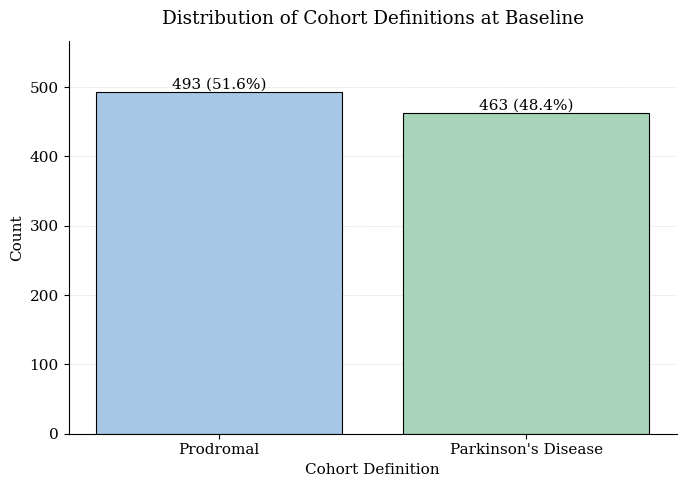

In [123]:

# Filtrar y contar
counts = (
    data_HY_v2.loc[data_HY_v2['EVENT_ID'].isin(['BL','V10_v2','V12_v3']), 'COHORT_DEFINITION']
    .value_counts()
)

total = counts.sum()
percentages = counts / total * 100

# Definir colores específicos
color_map = {
    "Prodromal": "#A7C7E7",   # azul pastel
    "Parkinson": "#A8D5BA"    # verde pastel
}

colors = [color_map.get(cat, "#A8D5BA") for cat in counts.index]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir count + porcentaje encima
for bar, count, pct in zip(bars, counts.values, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Distribution of Cohort Definitions at Baseline", pad=12)
ax.set_xlabel("Cohort Definition")
ax.set_ylabel("Count")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

plt.xticks(rotation=0)

# Añadir pequeño margen superior para que no se corte el texto
ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

# HY cambios

<bound method Spine.set of <matplotlib.spines.Spine object at 0x702649f33b90>>

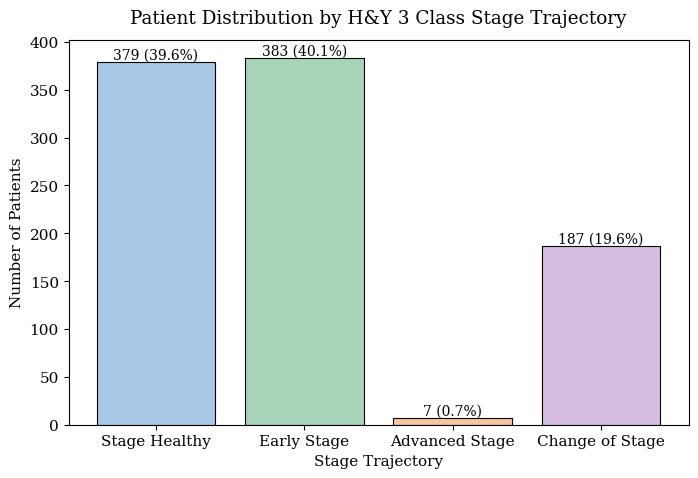

In [124]:
import pandas as pd
import matplotlib.pyplot as plt

counts = {
    'Stage Healthy': 0,
    'Early Stage': 0,
    'Advanced Stage': 0,
    'Change of Stage': 0
}

for patno in data_HY_v2['PATNO'].unique():
    subset_data = data_HY_v2[data_HY_v2['PATNO'] == patno]
    stages = subset_data['STAGE'].dropna().unique()

    if len(stages) > 1:
        counts['Change of Stage'] += 1

    elif len(stages) == 1:
        if stages[0] == 'Healthy':
            counts['Stage Healthy'] += 1

        elif stages[0] == 'Early Stage':
            counts['Early Stage'] += 1

        elif stages[0] == 'Advanced Stage':
            counts['Advanced Stage'] += 1


# Convertir a DataFrame manteniendo el orden clínico
counts_df = pd.DataFrame(
    list(counts.items()),
    columns=['Stage', 'Count']
)

total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100


# Colores pastel
color_map = {
    "Stage Healthy": "#A7C7E7",
    "Early Stage": "#A8D5BA",
    "Advanced Stage": "#F7C59F",
    "Change of Stage": "#D7BDE2"
}

colors = [color_map[stage] for stage in counts_df['Stage']]


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    counts_df['Stage'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir contador y porcentaje encima de cada barra
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title("Patient Distribution by H&Y 3 Class Stage Trajectory", pad=12)
ax.set_xlabel("Stage Trajectory")
ax.set_ylabel("Number of Patients")

# Estilo limpio
ax.spines['top'].set

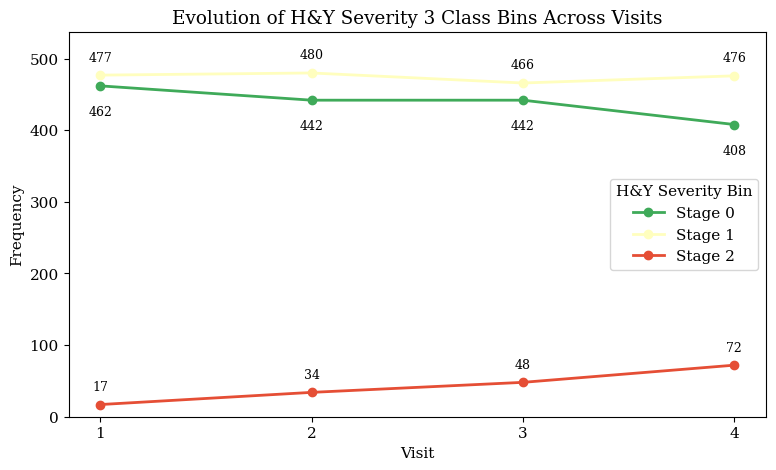

In [125]:

stage = [0, 1, 2]
events = [1, 2, 3, 4]

colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(stage)))

stage_counts = {s: [] for s in stage}

for event in events:
    subset_stage = df.loc[df['EVENT_ID'] == event, 'STAGE'].dropna()

    for s in stage:
        count = sum(subset_stage == s)
        stage_counts[s].append(count)

fig, ax = plt.subplots(figsize=(9, 5))

# Desplazamiento vertical de las etiquetas por clase
label_offsets = {
    0: -14,   # Stage 0: etiqueta debajo del punto
    1: 8,     # Stage 1: etiqueta encima del punto
    2: 8      # Stage 2: etiqueta encima del punto
}

vertical_alignment = {
    0: "top",
    1: "bottom",
    2: "bottom"
}

for s, color in zip(stage, colors):
    ax.plot(
        events,
        stage_counts[s],
        marker='o',
        linewidth=2,
        color=color,
        label=f"Stage {s}"
    )

    for event, count in zip(events, stage_counts[s]):
        ax.annotate(
            str(count),
            xy=(event, count),
            xytext=(0, label_offsets[s]),
            textcoords="offset points",
            ha="center",
            va=vertical_alignment[s],
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.7
            )
        )

ax.set_xlabel("Visit")
ax.set_ylabel("Frequency")
ax.set_title("Evolution of H&Y Severity 3 Class Bins Across Visits")
ax.set_xticks(events)

ax.set_ylim(0, max(max(v) for v in stage_counts.values()) * 1.12)

ax.legend(title="H&Y Severity Bin")

plt.show()

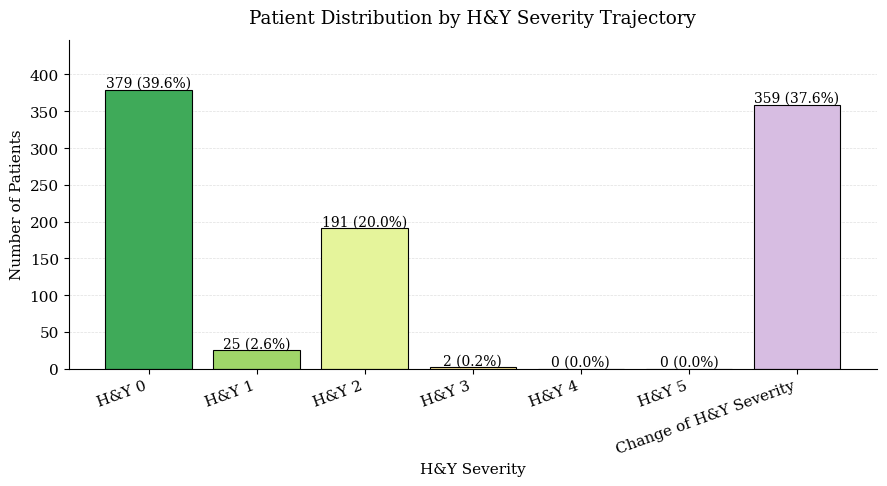

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

counts = {
    'H&Y 0': 0,
    'H&Y 1': 0,
    'H&Y 2': 0,
    'H&Y 3': 0,
    'H&Y 4': 0,
    'H&Y 5': 0,
    'Change of H&Y Severity': 0
}

for patno in data_HY_v2['PATNO'].unique():

    subset_data = data_HY_v2[data_HY_v2['PATNO'] == patno]
    nhy_values = subset_data['NHY'].unique()

    if len(nhy_values) > 1:
        counts['Change of H&Y Severity'] += 1

    elif len(nhy_values) == 1:
        severity = int(nhy_values[0])

        if severity in [0, 1, 2, 3, 4, 5]:
            counts[f'H&Y {severity}'] += 1


# Convertir a DataFrame manteniendo el orden clínico
counts_df = pd.DataFrame(
    list(counts.items()),
    columns=['Severity H&Y', 'Count']
)

total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100 if total > 0 else 0


# Colores: menor gravedad verde, mayor gravedad rojo
severity_colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, 6))

color_map = {
    'H&Y 0': severity_colors[0],
    'H&Y 1': severity_colors[1],
    'H&Y 2': severity_colors[2],
    'H&Y 3': severity_colors[3],
    'H&Y 4': severity_colors[4],
    'H&Y 5': severity_colors[5],
    'Change of H&Y Severity': '#D7BDE2'
}

colors = [color_map[label] for label in counts_df['Severity H&Y']]


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    counts_df['Severity H&Y'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir contador y porcentaje encima de cada barra
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title("Patient Distribution by H&Y Severity Trajectory", pad=12)
ax.set_xlabel("H&Y Severity")
ax.set_ylabel("Number of Patients")

# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.grid(
    True,
    linestyle='--',
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(True)

ax.set_xticks(range(len(counts_df['Severity H&Y'])))
ax.set_xticklabels(
    counts_df['Severity H&Y'],
    rotation=20,
    ha='right'
)

max_count = counts_df['Count'].max()
ax.set_ylim(0, max_count * 1.18 if max_count > 0 else 1)

plt.tight_layout()
plt.show()

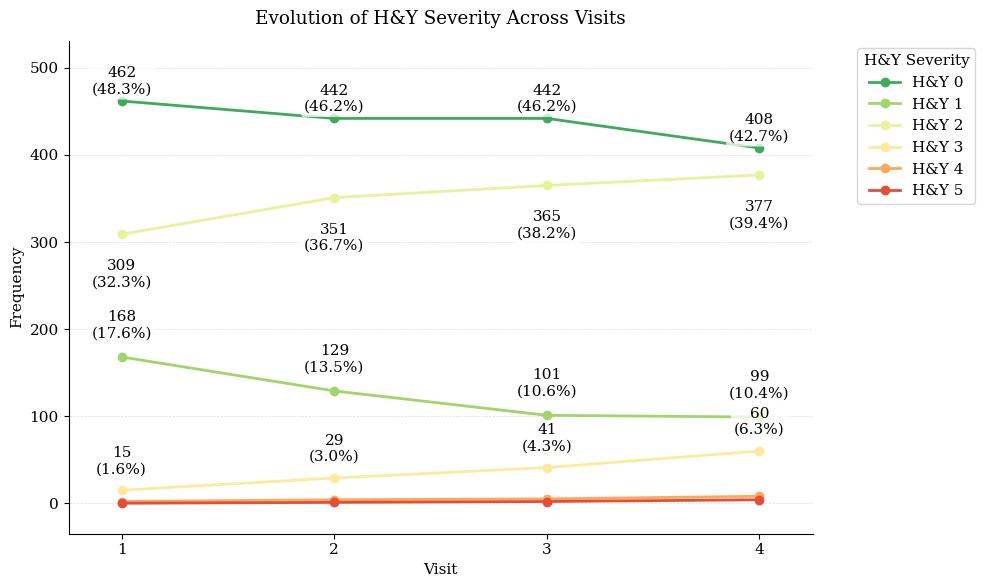

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# Clases H&Y y visitas
classes = [0, 1, 2, 3, 4, 5]
events = [1, 2, 3, 4]

# Colores: menor gravedad verde, mayor gravedad rojo
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(classes)))

# Diccionarios para guardar frecuencias y porcentajes
nhy_counts = {c: [] for c in classes}
nhy_percentages = {c: [] for c in classes}

# Calcular frecuencias por visita y clase
for event in events:
    subset_nhy = df.loc[df['EVENT_ID'] == event, 'NHY'].dropna()
    total = len(subset_nhy)

    for c in classes:
        count = sum(subset_nhy == c)
        percentage = (count / total) * 100 if total > 0 else 0

        nhy_counts[c].append(count)
        nhy_percentages[c].append(percentage)


# Estilo general
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(10, 6))


# Desplazamientos de etiquetas
label_offsets = {
    0: (0, 25),
    1: (0, 12),
    2: (0, -18),
    3: (0, 10)
}

vertical_alignment = {
    0: "top",
    1: "bottom",
    2: "top",
    3: "bottom"
}


# Plot de líneas
for c, color in zip(classes, colors):

    ax.plot(
        events,
        nhy_counts[c],
        marker="o",
        linewidth=2,
        markersize=6,
        color=color,
        label=f"H&Y {c}"
    )

    # No mostrar valores encima de H&Y 4 ni H&Y 5
    if c in [4, 5]:
        continue

    # Etiquetas con contador y porcentaje
    for event, count, percentage in zip(events, nhy_counts[c], nhy_percentages[c]):

        if count == 0:
            continue

        ax.annotate(
            f"{count}\n({percentage:.1f}%)",
            xy=(event, count),
            xytext=label_offsets[c],
            textcoords="offset points",
            ha="center",
            va=vertical_alignment[c],
            fontsize=11,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            )
        )


# Títulos y etiquetas
ax.set_xlabel("Visit")
ax.set_ylabel("Frequency")
ax.set_title("Evolution of H&Y Severity Across Visits", pad=12)

ax.set_xticks(events)

# Margen inferior para separar la zona cercana a 0 del eje X
max_count = max(max(v) for v in nhy_counts.values())
ax.set_ylim(-35, max_count * 1.15)

# Margen lateral
ax.set_xlim(min(events) - 0.25, max(events) + 0.25)


# Estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.grid(
    True,
    linestyle='--',
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(True)


# Leyenda
ax.legend(
    title="H&Y Severity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Delta UPDRS 3

In [ ]:
import numpy as np

delta_dic = {'V2_V1': [], 'V3_V2': [], 'V4_V3': []}

updrs3_cols = [
    'NP3SPCH', 'NP3FACXP', 'NP3RIGN', 'NP3RIGRU',
    'NP3RIGLU', 'NP3RIGRL', 'NP3RIGLL', 'NP3FTAPR', 'NP3FTAPL',
    'NP3HMOVR', 'NP3HMOVL', 'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR',
    'NP3TTAPL', 'NP3LGAGR', 'NP3LGAGL', 'NP3RISNG', 'NP3GAIT',
    'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR', 'NP3BRADY', 'NP3PTRMR',
    'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 'NP3RTARU', 'NP3RTALU',
    'NP3RTARL', 'NP3RTALL', 'NP3RTALJ', 'NP3RTCON'
]

dict_updrs = {
    'UPDRS3_V1': [],
    'UPDRS3_V2': [],
    'UPDRS3_V3': [],
    'UPDRS3_V4': []
}

for patno in data_HY_v2['PATNO'].unique():

    updrs_subset = data_HY_v2.loc[
        data_HY_v2['PATNO'] == patno,
        ['PATNO', 'EVENT_ID'] + updrs3_cols
    ].copy()

    updrs_subset['UPDRS_3_TOTAL'] = updrs_subset[updrs3_cols].sum(axis=1, min_count=1)

    data_id = updrs_subset[['PATNO', 'EVENT_ID', 'UPDRS_3_TOTAL']].copy()

    for event in [1, 2, 3, 4]:

        value = data_id.loc[
            data_id['EVENT_ID'] == event,
            'UPDRS_3_TOTAL'
        ]

        if len(value) > 0:
            dict_updrs[f'UPDRS3_V{event}'].append(value.iloc[0])
        else:
            dict_updrs[f'UPDRS3_V{event}'].append(np.nan)

    for event_pair in [[2, 1], [3, 2], [4, 3]]:

        value_final = data_id.loc[
            data_id['EVENT_ID'] == event_pair[0],
            'UPDRS_3_TOTAL'
        ]

        value_inicial = data_id.loc[
            data_id['EVENT_ID'] == event_pair[1],
            'UPDRS_3_TOTAL'
        ]

        if len(value_final) > 0 and len(value_inicial) > 0:
            increment = value_final.iloc[0] - value_inicial.iloc[0]
        else:
            increment = np.nan

        delta_dic[f'V{event_pair[0]}_V{event_pair[1]}'].append(increment)


print(dict_updrs)
print(delta_dic)

IndexError: index 0 is out of bounds for axis 0 with size 0

# STATISTICAL DESCRIPTION

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [10]:
# --- Cargar datos ---
path_data1 = project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_BL_V08.csv'
path_data2=project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_test.csv'
path_data3=project_root / 'DATA_PPMI/Results/MODEL_DATA/DATA_test2.csv'

data_HY1 = pd.read_csv(path_data1)

data_HY1['PATNO']=data_HY1['PATNO'].apply(lambda x: str(x)+'_v1')
data_HY2 = pd.read_csv(path_data2) # stage2 only
data_HY2['PATNO']=data_HY2['PATNO'].apply(lambda x: str(x)+'_v2')
data_HY3 = pd.read_csv(path_data3) # stage2 only
data_HY3['PATNO']=data_HY3['PATNO'].apply(lambda x: str(x)+'_v3')

data_HY2['EVENT_ID']=data_HY2['EVENT_ID'].apply(lambda x: x+'_v2')
data_HY3['EVENT_ID']=data_HY3['EVENT_ID'].apply(lambda x: x+'_v3')

def HY_classification(nhy):
    if nhy == 0 :
        return 'Healthy'
    elif nhy in [1,2] :
        return 'Early Stage'
    else:
        return 'Advanced Stage'

data_HY1['STAGE'] = data_HY1['NHY'].apply(HY_classification)
data_HY2['STAGE'] = data_HY2['NHY'].apply(HY_classification)
data_HY2_idx=data_HY2.loc[(data_HY2['EVENT_ID']=='V10_v2') & (data_HY2['STAGE']=='Advanced Stage'), 'PATNO']
data_HY2=data_HY2.loc[data_HY2['PATNO'].isin(data_HY2_idx), :]
data_HY3['STAGE'] = data_HY3['NHY'].apply(HY_classification)
data_HY3_idx=data_HY3.loc[(data_HY3['EVENT_ID']=='V12_v3') & (data_HY3['STAGE']=='Advanced Stage'), 'PATNO']
data_HY3=data_HY3.loc[data_HY3['PATNO'].isin(data_HY3_idx), :]

data_HY=pd.concat([data_HY1,data_HY2,data_HY3]).drop(columns=['Unnamed: 0'])



## AGE

In [11]:
age_data = data_HY[['PATNO','EVENT_ID', 'AGE_AT_VISIT']].copy()
age_data=age_data.loc[age_data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
age_data['AGE_AT_VISIT']

2       58.8
6       62.9
10      76.2
14      77.8
18      73.7
        ... 
866     56.3
886     84.9
1026    83.2
1030    64.2
1310    68.6
Name: AGE_AT_VISIT, Length: 956, dtype: float64

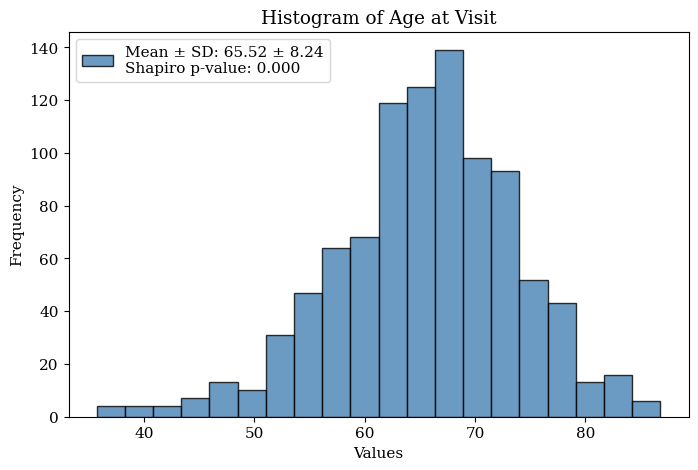

In [12]:
# Global style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

data = age_data['AGE_AT_VISIT'].to_list()

# Statistics
mean = np.mean(data)
std = np.std(data)

# Normality test (Shapiro-Wilk)
stat, p_value = stats.shapiro(data)

# Plot
plt.figure(figsize=(8,5))

plt.hist(
    data,
    bins=20,
    color="steelblue",
    edgecolor="black",
    alpha=0.8,
    label=f"Mean ± SD: {mean:.2f} ± {std:.2f}\nShapiro p-value: {p_value:.3f}"
)

plt.title("Histogram of Age at Visit")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.legend()

plt.show()

## SEX

In [13]:
sex_data = data_HY[['PATNO','EVENT_ID', 'SEX']].copy()
sex_data=sex_data.loc[sex_data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
sex_data

,PATNO,EVENT_ID,SEX
2,3003_v1,V06,0.0
6,3018_v1,V06,0.0
10,3020_v1,V06,0.0
14,3028_v1,V06,1.0
18,3051_v1,V06,1.0
...,...,...,...
866,51551_v3,V10_v3,0.0
886,51844_v3,V10_v3,0.0
1026,56169_v3,V10_v3,0.0
1030,56435_v3,V10_v3,1.0


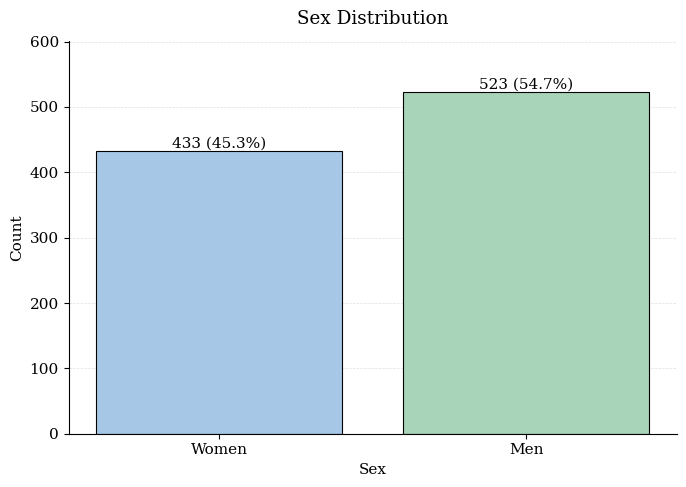

In [14]:
import matplotlib.pyplot as plt

# Count values
counts = sex_data['SEX'].value_counts().sort_index()

total = counts.sum()
percentages = counts / total * 100

# Map numeric values to labels
label_map = {
    0: "Women",
    1: "Men"
}

labels = [label_map.get(cat, str(cat)) for cat in counts.index]

# Colors (match categories)
color_map = {
    0: "#A7C7E7",   # pastel blue (Women)
    1: "#A8D5BA"    # pastel green (Men)
}

colors = [color_map.get(cat, "#A8D5BA") for cat in counts.index]

# Style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    labels,                # 👈 use labels instead of raw values
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Add count + percentage
for bar, count, pct in zip(bars, counts.values, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Sex Distribution", pad=12)
ax.set_xlabel("Sex")
ax.set_ylabel("Count")

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

## RACE

In [15]:
race_data = data_HY[['PATNO','EVENT_ID', 'RAWHITE']].copy()
race_data=race_data.loc[race_data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]

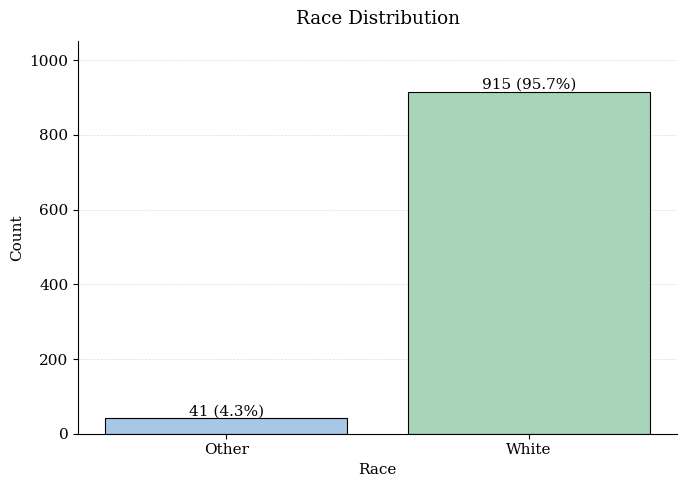

In [16]:
import matplotlib.pyplot as plt

# Count values
counts = race_data['RAWHITE'].value_counts().sort_index()

total = counts.sum()
percentages = counts / total * 100

# Map numeric values to labels
label_map = {
    0: "Other",
    1: "White"
}

labels = [label_map.get(cat, str(cat)) for cat in counts.index]

# Colors (match categories)
color_map = {
    0: "#A7C7E7",   # pastel blue (Women)
    1: "#A8D5BA"    # pastel green (Men)
}

colors = [color_map.get(cat, "#A8D5BA") for cat in counts.index]

# Style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    labels,                
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Add count + percentage
for bar, count, pct in zip(bars, counts.values, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Race Distribution", pad=12)
ax.set_xlabel("Race")
ax.set_ylabel("Count")

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

## EDUCATION_YEARS

In [17]:
studies_data = data_HY[['PATNO','EVENT_ID', 'EDUCYRS']].copy()
studies_data=studies_data.loc[studies_data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]

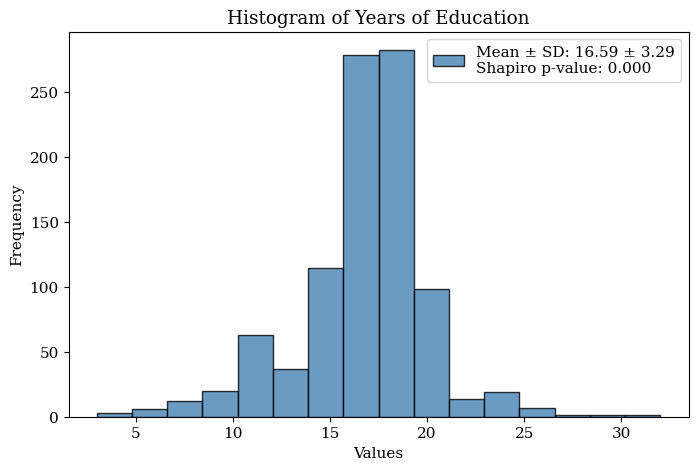

In [18]:
# Global style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

data = studies_data['EDUCYRS'].to_list()

# Statistics
mean = np.mean(data)
std = np.std(data)

# Normality test (Shapiro-Wilk)
stat, p_value = stats.shapiro(data)

# Plot
plt.figure(figsize=(8,5))

plt.hist(
    data,
    bins=16,
    color="steelblue",
    edgecolor="black",
    alpha=0.8,
    label=f"Mean ± SD: {mean:.2f} ± {std:.2f}\nShapiro p-value: {p_value:.3f}"
)

plt.title("Histogram of Years of Education")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.legend()

plt.show()

## GENETIC MUTATION

In [19]:
gen_data = data_HY[['PATNO','EVENT_ID', 'ENRLLRRK2','ENRLGBA']].copy()
gen_data = gen_data.loc[gen_data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]

for idx, row in gen_data.iterrows():
    if row['ENRLLRRK2'] == 1 and row['ENRLGBA'] == 1:
        gen_data.at[idx, 'GENETIC_RISK'] = 'LRRK2 + GBA'
    elif row['ENRLLRRK2'] == 1:
        gen_data.at[idx, 'GENETIC_RISK'] = 'LRRK2'
    elif row['ENRLGBA'] == 1:
        gen_data.at[idx, 'GENETIC_RISK'] = 'GBA'
    else:
        gen_data.at[idx, 'GENETIC_RISK'] = 'None'


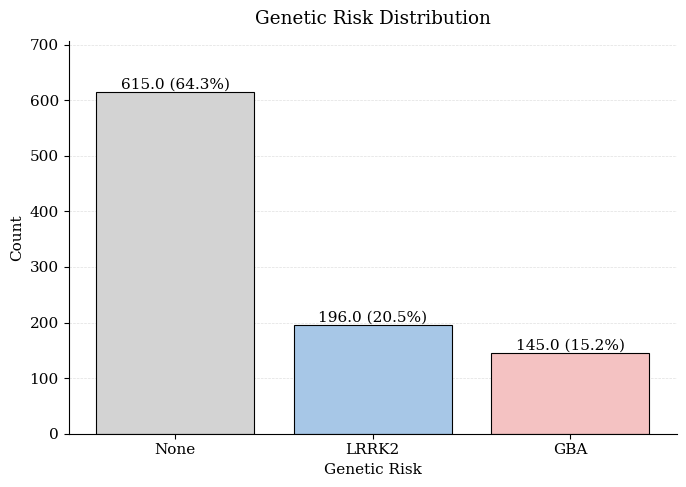

In [20]:
import matplotlib.pyplot as plt

# Count values
counts = gen_data['GENETIC_RISK'].value_counts()

total = counts.sum()
percentages = counts / total * 100

# Optional: define order
order = ['None', 'LRRK2', 'GBA', 'LRRK2 + GBA']
counts = counts.reindex(order).dropna()
percentages = percentages.reindex(counts.index)

# Colors
color_map = {
    'None': "#D3D3D3",        # light gray
    'LRRK2': "#A7C7E7",       # pastel blue
    'GBA': "#F4C2C2",         # pastel pink
    'LRRK2 + GBA': "#A8D5BA"  # pastel green
}

colors = [color_map.get(cat, "#A8D5BA") for cat in counts.index]

# Style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Add count + percentage
for bar, count, pct in zip(bars, counts.values, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Genetic Risk Distribution", pad=12)
ax.set_xlabel("Genetic Risk")
ax.set_ylabel("Count")

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

# STATISTICAL INFERENCE

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import scikit_posthocs as sp

def kruskal_full_analysis(df, col_num, col_cat, alpha=0.05, plot=True):
    plt.rcParams.update({'font.size': 15})
    """
    Run Kruskal-Wallis test, optional Dunn post-hoc test, and plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    col_num : str
        Numeric column name.
    col_cat : str
        Categorical column name.
    alpha : float, default=0.05
        Significance level.
    plot : bool, default=True
        Whether to show plots.

    Returns
    -------
    dict
        Dictionary with Kruskal-Wallis results and, if significant,
        Dunn post-hoc p-value matrix.
    """

    # Clean data
    if col_num not in df.columns or col_cat not in df.columns:
        raise ValueError(f"Columns '{col_num}' and/or '{col_cat}' not found in DataFrame.")

    data = df[[col_num, col_cat]].dropna()

    if data.empty:
        raise ValueError("No data left after dropping missing values.")

    # Build groups
    grouped = data.groupby(col_cat)[col_num]
    groups = [group.values for _, group in grouped]

    if len(groups) < 2:
        raise ValueError("At least two groups are required for Kruskal-Wallis.")

    # Kruskal-Wallis test
    stat, p_value = kruskal(*groups)

    results = {
        "kruskal_statistic": stat,
        "p_value": p_value,
        "significant": p_value < alpha
    }

    posthoc = None

    # Dunn post-hoc if significant
    if p_value < alpha:
        posthoc = sp.posthoc_dunn(
            data,
            val_col=col_num,
            group_col=col_cat,
            p_adjust="bonferroni"
        )
        results["posthoc_dunn"] = posthoc

    # Plots
    if plot:
        if posthoc is not None:
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            # Boxplot
            data.boxplot(column=col_num, by=col_cat, ax=axes[0])
            axes[0].set_title(f"{col_num} by {col_cat}")
            axes[0].set_xlabel(col_cat)
            axes[0].set_ylabel(col_num)
            plt.setp(axes[0].get_xticklabels(), rotation=0, ha="center")

            # Heatmap for Dunn post-hoc p-values
            cmap = "RdYlGn_r"
            im = axes[1].imshow(posthoc.values, aspect="auto", vmin=0, vmax=1, cmap=cmap)

            axes[1].set_xticks(np.arange(len(posthoc.columns)))
            axes[1].set_yticks(np.arange(len(posthoc.index)))
            axes[1].set_xticklabels(posthoc.columns)
            axes[1].set_yticklabels(posthoc.index)
            plt.setp(axes[1].get_xticklabels(), rotation=0, ha="center")

            for i in range(posthoc.shape[0]):
                for j in range(posthoc.shape[1]):
                    val = posthoc.iloc[i, j]
                    text_color = "white" if val < 0.3 else "black"
                    axes[1].text(
                        j, i,
                        f"{val:.3f}",
                        ha="center",
                        va="center",
                        color=text_color
                    )

            axes[1].set_title("Dunn post-hoc p-values")
            axes[1].set_xlabel(col_cat)
            axes[1].set_ylabel(col_cat)

            fig.colorbar(im, ax=axes[1], label="Adjusted p-value")
            plt.suptitle("")
            plt.tight_layout()
            plt.show()

        else:
            plt.figure(figsize=(7, 5))
            data.boxplot(column=col_num, by=col_cat)
            plt.title(f"{col_num} by {col_cat}")
            plt.suptitle("")
            plt.xlabel(col_cat)
            plt.ylabel(col_num)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()

    return results

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def chi2_full_visual(df, col_cat1, col_cat2, alpha=0.05, plot=True):
    plt.rcParams.update({'font.size': 15})
    """
    df: pandas DataFrame
    col_cat1: first categorical column
    col_cat2: second categorical column
    alpha: significance level
    plot: whether to show plots
    """
    
    # Clean data
    data = df[[col_cat1, col_cat2]].dropna()
    
    # Contingency table
    observed = pd.crosstab(data[col_cat1], data[col_cat2])
    
    # Chi-square test
    chi2_stat, p_value, dof, expected = chi2_contingency(observed)
    
    expected_df = pd.DataFrame(
        expected,
        index=observed.index,
        columns=observed.columns
    )
    
    # Standardized residuals
    residuals = (observed - expected_df) / np.sqrt(expected_df)
    
    results = {
        "chi2_statistic": chi2_stat,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "significant": p_value < alpha,
        "observed": observed,
        "expected": expected_df,
        "residuals": residuals
    }
    
    # -----------------------
    # PLOTS
    # -----------------------
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. Barplot (stacked)
        observed.plot(kind="bar", stacked=True, ax=axes[0])
        axes[0].set_title(f"Barplot: {col_cat1} vs {col_cat2}")
        axes[0].set_xlabel(col_cat1)
        axes[0].set_ylabel("Count")
        axes[0].legend(title=col_cat2)
        plt.setp(axes[0].get_xticklabels(), rotation=0,  ha="center")
        # 2. Heatmap de residuos
        im = axes[1].imshow(residuals.values, aspect='auto', vmin=-4, vmax=4)
        
        axes[1].set_xticks(np.arange(len(residuals.columns)))
        axes[1].set_yticks(np.arange(len(residuals.index)))
        axes[1].set_xticklabels(residuals.columns)
        axes[1].set_yticklabels(residuals.index)
        
        plt.setp(axes[1].get_xticklabels(),  ha="center")
        
        # Añadir valores en cada celda
        for i in range(residuals.shape[0]):
            for j in range(residuals.shape[1]):
                axes[1].text(
                    j, i,
                    f"{residuals.iloc[i, j]:.2f}",
                    ha="center", va="center"
                )
        
        axes[1].set_title("Standardized Residuals")
        axes[1].set_xlabel(col_cat2)
        axes[1].set_ylabel(col_cat1)
        
        fig.colorbar(im, ax=axes[1], label="Residual")
        
        plt.tight_layout()
        plt.show()
    
    return results

## SEX-AGE

In [23]:
data = data_HY[['PATNO','EVENT_ID', 'AGE_AT_VISIT','SEX']].copy()
data['SEX']=data['SEX'].apply(lambda x: 'MEN' if x==1 else 'WOMAN')
data=data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]

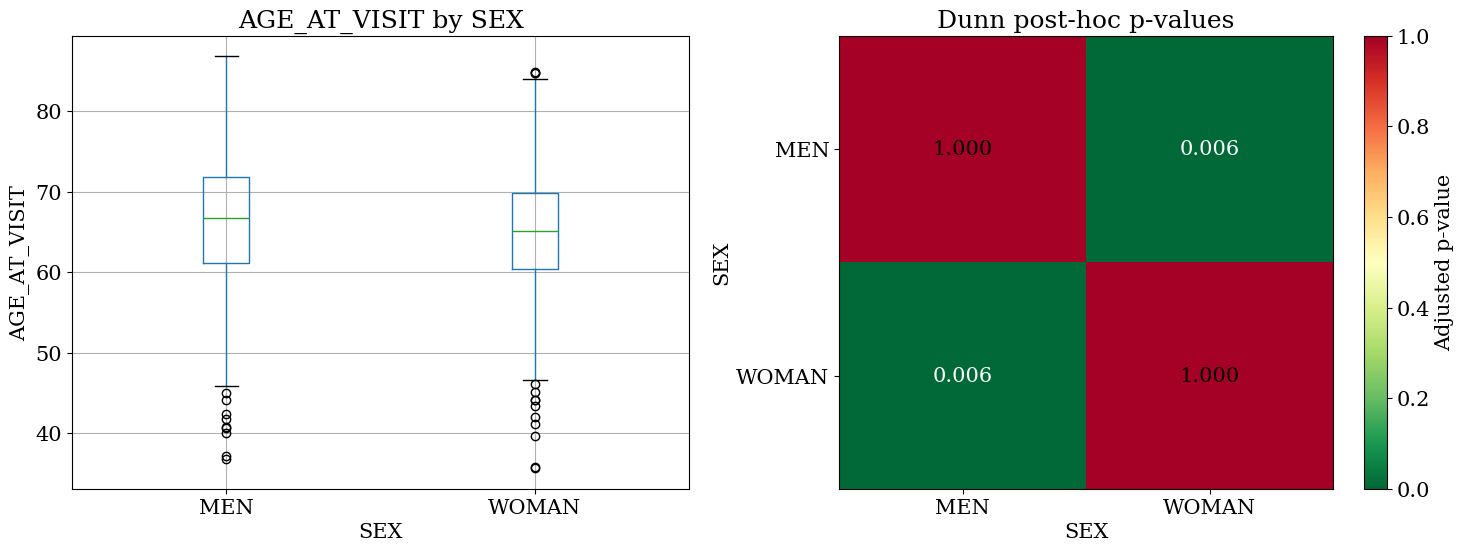

{'kruskal_statistic': np.float64(7.6656503623790035), 'p_value': np.float64(0.005628196979567013), 'significant': np.True_, 'posthoc_dunn':             MEN     WOMAN
MEN    1.000000  0.005628
WOMAN  0.005628  1.000000}


In [24]:
result = kruskal_full_analysis(data, "AGE_AT_VISIT", "SEX")
print(result)


## SEX-GEN

In [25]:
data = data_HY[['PATNO','EVENT_ID', 'AGE_AT_VISIT','ENRLLRRK2','ENRLGBA','SEX']].copy()
data['SEX']=data['SEX'].apply(lambda x: 'MEN' if x==1 else 'WOMAN')
data=data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
for idx, row in data.iterrows():
    if row['ENRLLRRK2'] == 1 and row['ENRLGBA'] == 1:
        data.at[idx, 'GENETIC_RISK'] = 'LRRK2 + GBA'
    elif row['ENRLLRRK2'] == 1:
        data.at[idx, 'GENETIC_RISK'] = 'LRRK2'
    elif row['ENRLGBA'] == 1:
        data.at[idx, 'GENETIC_RISK'] = 'GBA'
    else:
        data.at[idx, 'GENETIC_RISK'] = 'None'
data

,PATNO,EVENT_ID,AGE_AT_VISIT,ENRLLRRK2,ENRLGBA,SEX,GENETIC_RISK
2,3003_v1,V06,58.8,0,0,WOMAN,None
6,3018_v1,V06,62.9,0,0,WOMAN,None
10,3020_v1,V06,76.2,0,0,WOMAN,None
14,3028_v1,V06,77.8,0,0,MEN,None
18,3051_v1,V06,73.7,0,0,MEN,None
...,...,...,...,...,...,...,...
866,51551_v3,V10_v3,56.3,0,1,WOMAN,GBA
886,51844_v3,V10_v3,84.9,0,1,WOMAN,GBA
1026,56169_v3,V10_v3,83.2,1,0,WOMAN,LRRK2
1030,56435_v3,V10_v3,64.2,0,1,MEN,GBA


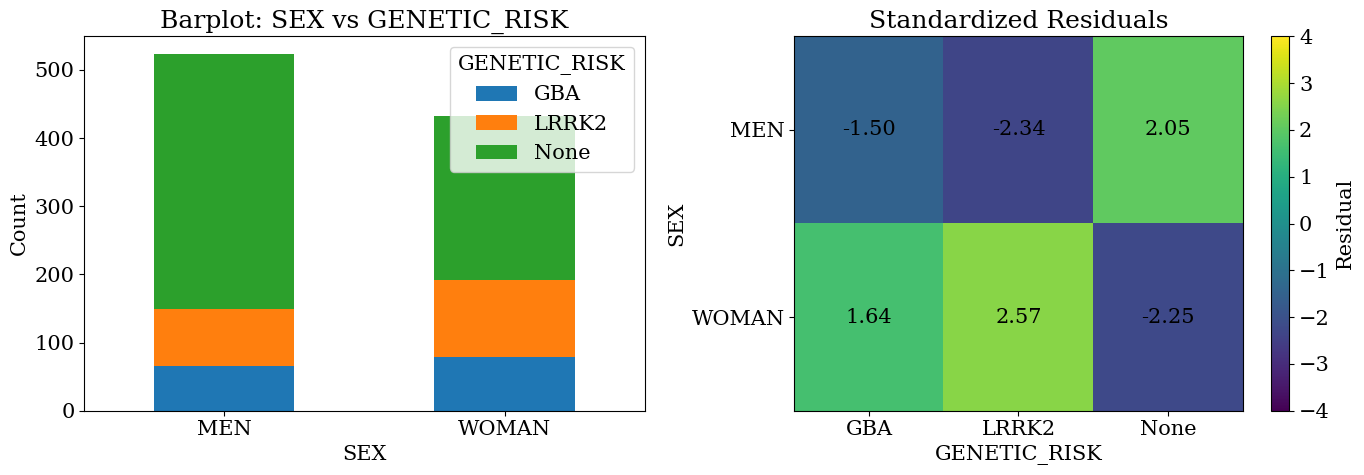

{'chi2_statistic': np.float64(26.28006630687149),
 'p_value': np.float64(1.964970838058747e-06),
 'degrees_of_freedom': 2,
 'significant': np.True_,
 'observed': GENETIC_RISK  GBA  LRRK2  None
 SEX                           
 MEN            66     83   374
 WOMAN          79    113   241,
 'expected': GENETIC_RISK        GBA       LRRK2        None
 SEX                                            
 MEN           79.325314  107.225941  336.448745
 WOMAN         65.674686   88.774059  278.551255,
 'residuals': GENETIC_RISK       GBA     LRRK2      None
 SEX                                       
 MEN          -1.496138 -2.339541  2.047222
 WOMAN         1.644290  2.571210 -2.249945}

In [26]:
chi2_full_visual(data, col_cat1='SEX', col_cat2='GENETIC_RISK', alpha=0.05, plot=True)

# AGE-HY3 STAGE

In [27]:
data = data_HY[['PATNO','EVENT_ID', 'AGE_AT_VISIT','STAGE']].copy()
data=data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]

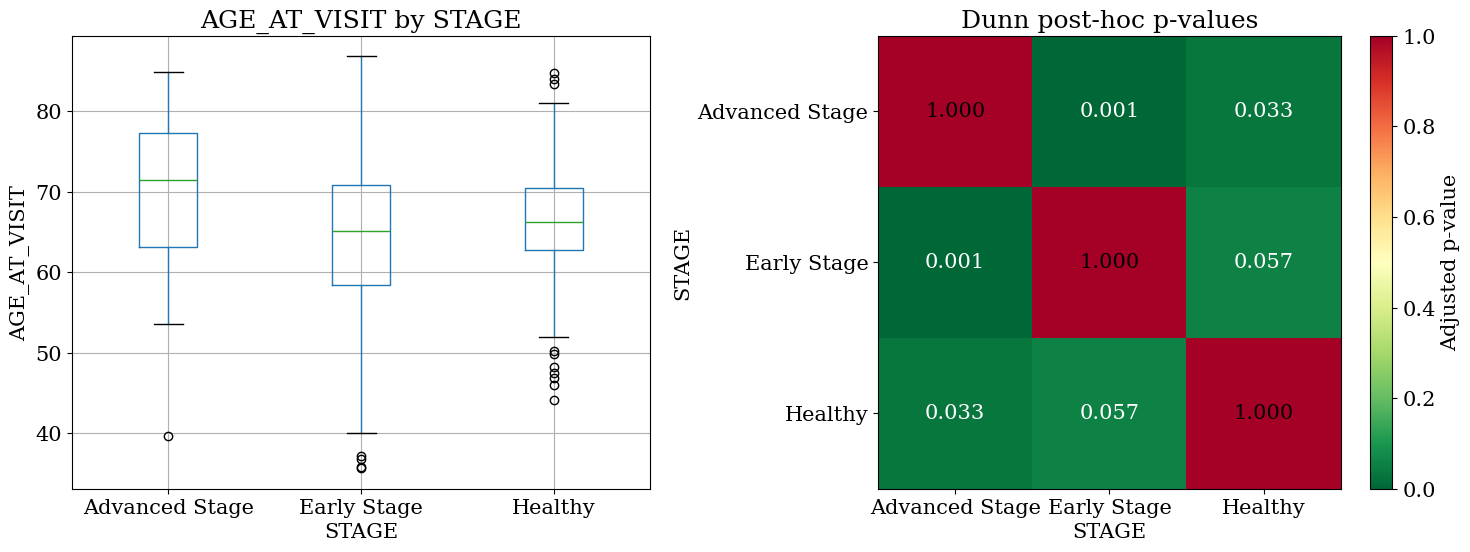

{'kruskal_statistic': np.float64(15.443374469092602), 'p_value': np.float64(0.0004431123383854534), 'significant': np.True_, 'posthoc_dunn':                 Advanced Stage  Early Stage   Healthy
Advanced Stage        1.000000     0.001026  0.032503
Early Stage           0.001026     1.000000  0.057180
Healthy               0.032503     0.057180  1.000000}


In [28]:
result = kruskal_full_analysis(data, "AGE_AT_VISIT", "STAGE")
print(result)

## UPDRS Domain VS STAGE_output

In [29]:
cols_data = data_HY.columns.to_list()
data=data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
UPDRS_NO_MOTOR = [col for col in cols_data if col.startswith('NP1')]
UPDRS_IMPACTO_MOTOR = [col for col in cols_data if col.startswith('NP2')]
UPDRS_MOTOR =[col for col in cols_data if col.startswith('NP3')]


### UPDRS 1

In [30]:
data = data_HY[['PATNO','EVENT_ID','STAGE'] + UPDRS_NO_MOTOR].copy()
data = data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
data['UPDRS1'] = data[UPDRS_NO_MOTOR].sum(axis=1)
data[['PATNO','EVENT_ID','STAGE','UPDRS1']]

,PATNO,EVENT_ID,STAGE,UPDRS1
2,3003_v1,V06,Early Stage,7.0
6,3018_v1,V06,Early Stage,9.0
10,3020_v1,V06,Advanced Stage,12.0
14,3028_v1,V06,Early Stage,3.0
18,3051_v1,V06,Early Stage,5.0
...,...,...,...,...
866,51551_v3,V10_v3,Early Stage,8.0
886,51844_v3,V10_v3,Advanced Stage,5.0
1026,56169_v3,V10_v3,Advanced Stage,12.0
1030,56435_v3,V10_v3,Early Stage,12.0


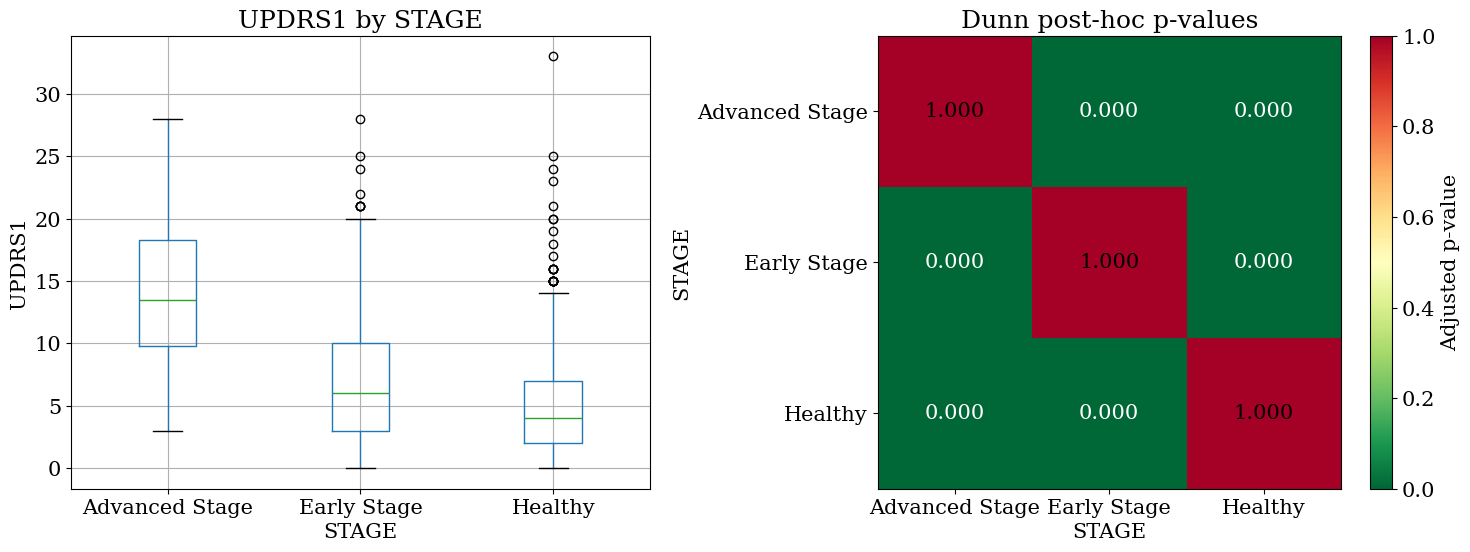

{'kruskal_statistic': np.float64(97.90899386901572), 'p_value': np.float64(5.486964078288603e-22), 'significant': np.True_, 'posthoc_dunn':                 Advanced Stage   Early Stage       Healthy
Advanced Stage    1.000000e+00  1.018164e-10  2.053123e-19
Early Stage       1.018164e-10  1.000000e+00  2.456901e-08
Healthy           2.053123e-19  2.456901e-08  1.000000e+00}


In [31]:
result = kruskal_full_analysis(data, "UPDRS1", "STAGE")
print(result)

### UPDRS 2

In [32]:
data = data_HY[['PATNO','EVENT_ID','STAGE'] + UPDRS_IMPACTO_MOTOR].copy()
data = data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
data['UPDRS2'] = data[UPDRS_IMPACTO_MOTOR].sum(axis=1)
data[['PATNO','EVENT_ID','STAGE','UPDRS2']]

,PATNO,EVENT_ID,STAGE,UPDRS2
2,3003_v1,V06,Early Stage,7.0
6,3018_v1,V06,Early Stage,13.0
10,3020_v1,V06,Advanced Stage,11.0
14,3028_v1,V06,Early Stage,7.0
18,3051_v1,V06,Early Stage,4.0
...,...,...,...,...
866,51551_v3,V10_v3,Early Stage,7.0
886,51844_v3,V10_v3,Advanced Stage,18.0
1026,56169_v3,V10_v3,Advanced Stage,15.0
1030,56435_v3,V10_v3,Early Stage,17.0


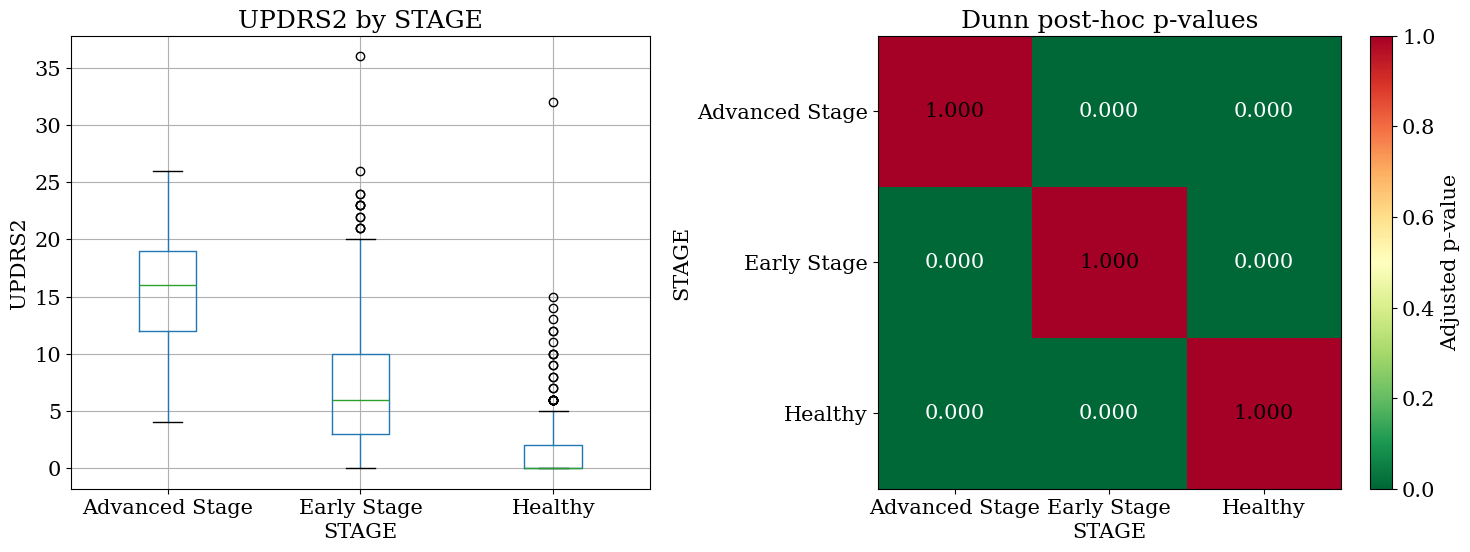

{'kruskal_statistic': np.float64(455.8011714549671), 'p_value': np.float64(1.0568982919387496e-99), 'significant': np.True_, 'posthoc_dunn':                 Advanced Stage   Early Stage       Healthy
Advanced Stage    1.000000e+00  7.215449e-09  5.891475e-45
Early Stage       7.215449e-09  1.000000e+00  5.312498e-78
Healthy           5.891475e-45  5.312498e-78  1.000000e+00}


In [33]:
result = kruskal_full_analysis(data, "UPDRS2", "STAGE")
print(result)

### UPDRS 3

In [34]:
data = data_HY[['PATNO','EVENT_ID','STAGE'] + UPDRS_MOTOR].copy()
data = data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
data['UPDRS3'] = data[UPDRS_MOTOR].sum(axis=1)
data[['PATNO','EVENT_ID','STAGE','UPDRS3']]

,PATNO,EVENT_ID,STAGE,UPDRS3
2,3003_v1,V06,Early Stage,43.0
6,3018_v1,V06,Early Stage,35.0
10,3020_v1,V06,Advanced Stage,36.0
14,3028_v1,V06,Early Stage,49.0
18,3051_v1,V06,Early Stage,19.0
...,...,...,...,...
866,51551_v3,V10_v3,Early Stage,39.0
886,51844_v3,V10_v3,Advanced Stage,45.0
1026,56169_v3,V10_v3,Advanced Stage,22.0
1030,56435_v3,V10_v3,Early Stage,18.0


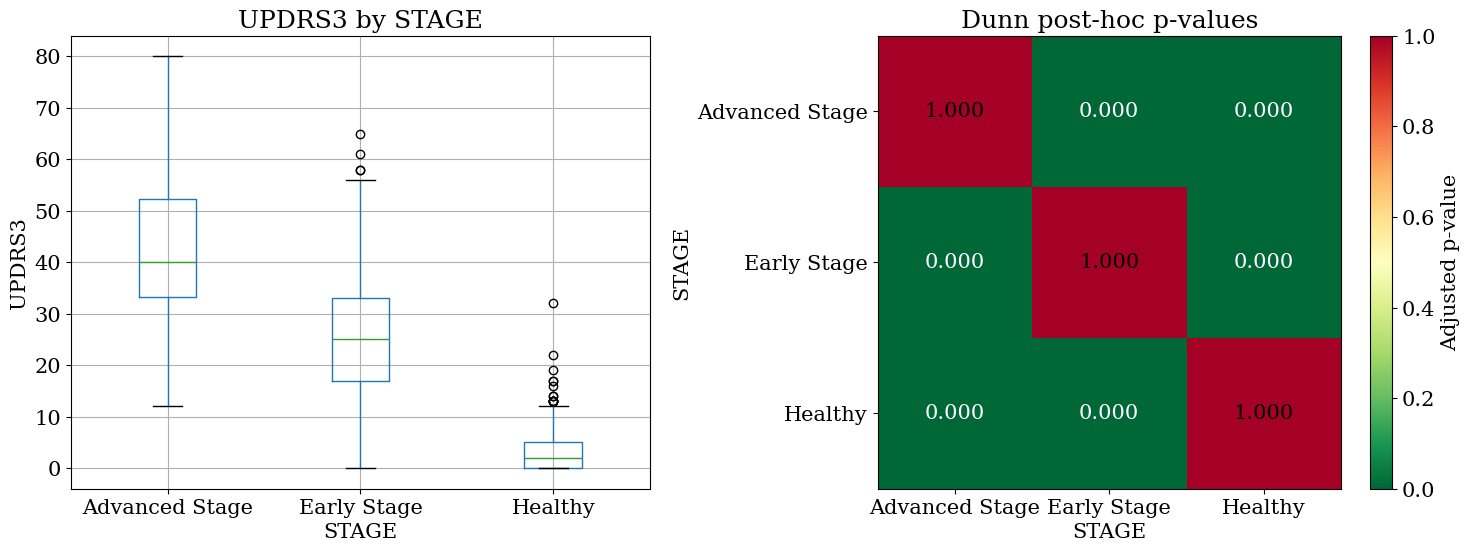

{'kruskal_statistic': np.float64(689.8372747892117), 'p_value': np.float64(1.5985972956366317e-150), 'significant': np.True_, 'posthoc_dunn':                 Advanced Stage    Early Stage        Healthy
Advanced Stage    1.000000e+00   2.954164e-04   7.405944e-48
Early Stage       2.954164e-04   1.000000e+00  1.400769e-132
Healthy           7.405944e-48  1.400769e-132   1.000000e+00}


In [35]:
result = kruskal_full_analysis(data, "UPDRS3", "STAGE")
print(result)

### TOTAL UPDRS

In [36]:
data = data_HY[['PATNO','EVENT_ID','STAGE'] + UPDRS_MOTOR+ UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR].copy()
data = data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]
data['UPDRS_TOTAL'] = data[UPDRS_MOTOR + UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR].sum(axis=1)
data[['PATNO','EVENT_ID','STAGE','UPDRS_TOTAL']]

,PATNO,EVENT_ID,STAGE,UPDRS_TOTAL
2,3003_v1,V06,Early Stage,57.0
6,3018_v1,V06,Early Stage,57.0
10,3020_v1,V06,Advanced Stage,59.0
14,3028_v1,V06,Early Stage,59.0
18,3051_v1,V06,Early Stage,28.0
...,...,...,...,...
866,51551_v3,V10_v3,Early Stage,54.0
886,51844_v3,V10_v3,Advanced Stage,68.0
1026,56169_v3,V10_v3,Advanced Stage,49.0
1030,56435_v3,V10_v3,Early Stage,47.0


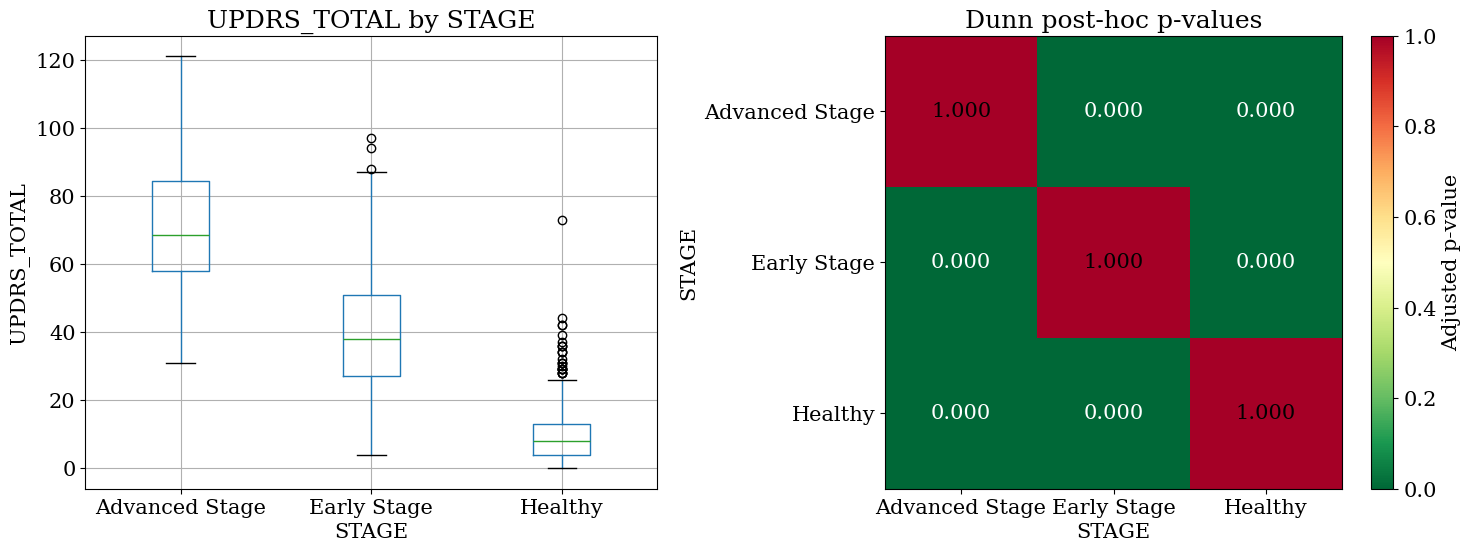

{'kruskal_statistic': np.float64(629.6791138348077), 'p_value': np.float64(1.8489184061244795e-137), 'significant': np.True_, 'posthoc_dunn':                 Advanced Stage    Early Stage        Healthy
Advanced Stage    1.000000e+00   6.023938e-07   1.442949e-51
Early Stage       6.023938e-07   1.000000e+00  2.408769e-115
Healthy           1.442949e-51  2.408769e-115   1.000000e+00}


In [37]:
result = kruskal_full_analysis(data, "UPDRS_TOTAL", "STAGE")
print(result)

# Delta UPDRS Futuro

In [38]:
data = data_HY[['PATNO','EVENT_ID','STAGE'] + UPDRS_MOTOR + UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR].copy()
data = data.loc[data['EVENT_ID'].isin(['V06','V08','V08_v2','V10_v2','V10_v3','V12_v3']), :]
data['EVENT_ID'] = data['EVENT_ID'].apply(lambda x: 'Vi' if x in ['V06','V08_v2','V10_v3'] else 'Vf')
data['UPDRS_TOTAL'] = data[UPDRS_MOTOR + UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR].sum(axis=1)
data = data[['PATNO','EVENT_ID','STAGE','UPDRS_TOTAL']].copy()

# Pasar a ancho
data_wide = data.pivot_table(
    index='PATNO',
    columns='EVENT_ID',
    values='UPDRS_TOTAL',
    aggfunc='first'
)

# Delta
data_wide['DELTA_UPDRS'] = data_wide['Vf'] - data_wide['Vi']

# Reset index
data_final = data_wide.reset_index()

# Extraer STAGE de Vf
stage_vf = (
    data.loc[data['EVENT_ID'] == 'Vf', ['PATNO', 'STAGE']]
    .drop_duplicates(subset='PATNO')
)

# Unir por PATNO
data_final = data_final.merge(stage_vf, on='PATNO', how='left')

data_final

,PATNO,Vf,Vi,DELTA_UPDRS,STAGE
0,100001_v1,59.0,53.0,6.0,Early Stage
1,100006_v1,48.0,52.0,-4.0,Early Stage
2,100007_v1,44.0,39.0,5.0,Early Stage
3,100012_v1,58.0,39.0,19.0,Early Stage
4,100017_v1,25.0,24.0,1.0,Early Stage
...,...,...,...,...,...
951,75570_v1,0.0,0.0,0.0,Healthy
952,85236_v1,4.0,3.0,1.0,Healthy
953,85242_v1,13.0,4.0,9.0,Early Stage
954,90456_v1,36.0,37.0,-1.0,Early Stage


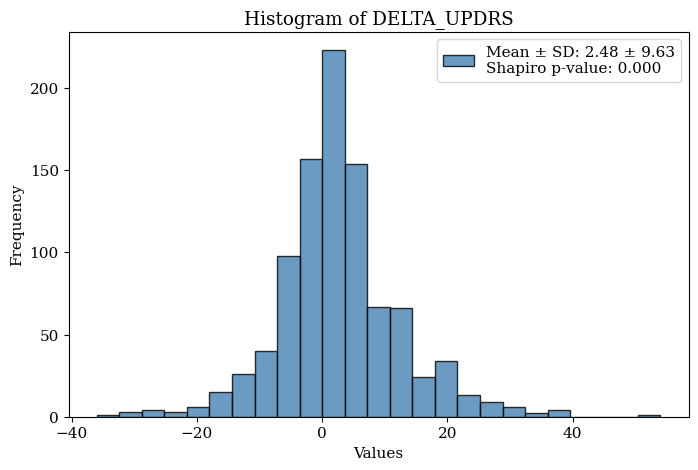

In [39]:
# Global style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

data = data_final['DELTA_UPDRS'].to_list()

# Statistics
mean = np.mean(data)
std = np.std(data)

# Normality test (Shapiro-Wilk)
stat, p_value = stats.shapiro(data)

# Plot
plt.figure(figsize=(8,5))

plt.hist(
    data,
    bins=25,
    color="steelblue",
    edgecolor="black",
    alpha=0.8,
    label=f"Mean ± SD: {mean:.2f} ± {std:.2f}\nShapiro p-value: {p_value:.3f}"
)

plt.title("Histogram of DELTA_UPDRS")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.legend()

plt.show()

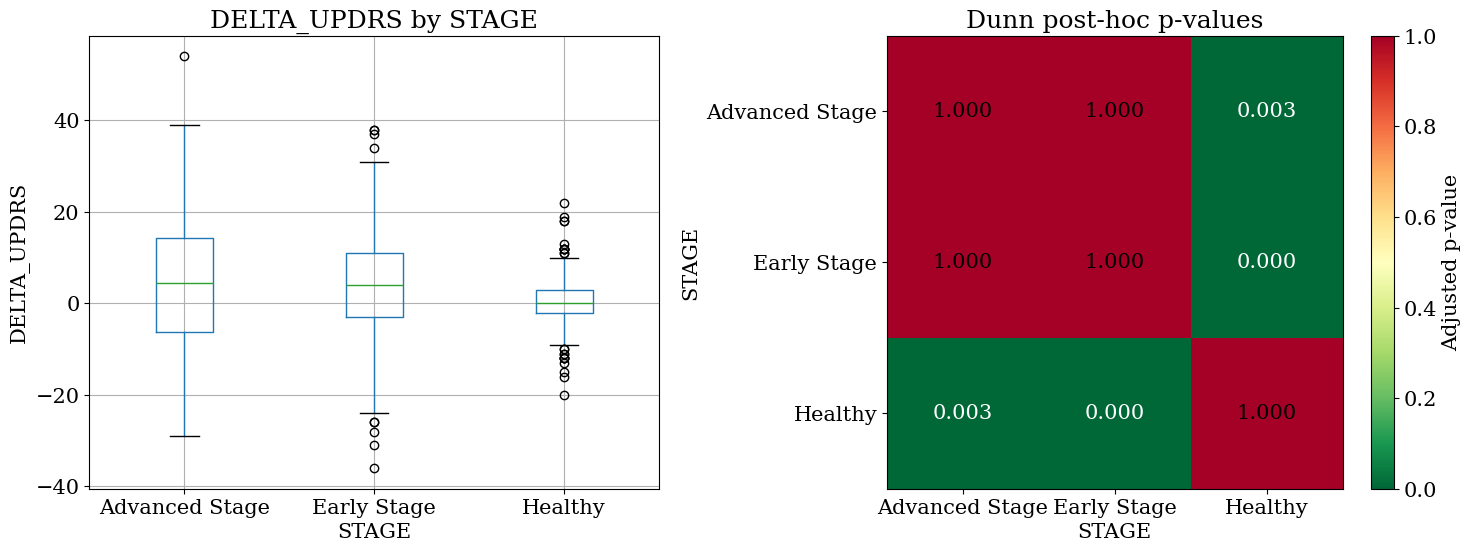

{'kruskal_statistic': np.float64(48.59681091296824), 'p_value': np.float64(2.801151454647479e-11), 'significant': np.True_, 'posthoc_dunn':                 Advanced Stage   Early Stage       Healthy
Advanced Stage        1.000000  1.000000e+00  3.114067e-03
Early Stage           1.000000  1.000000e+00  2.550692e-11
Healthy               0.003114  2.550692e-11  1.000000e+00}


In [40]:
result = kruskal_full_analysis(data_final, "DELTA_UPDRS", "STAGE")
print(result)

In [41]:
data = data_HY[['PATNO','EVENT_ID','STAGE'] + UPDRS_MOTOR + UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR].copy()
data = data.loc[data['EVENT_ID'].isin(['V04','V06','V06_v2','V08_v2','V08_v3','V10_v3']), :]
data['EVENT_ID'] = data['EVENT_ID'].apply(lambda x: 'Vi' if x in ['V04','V06_v2','V08_v3'] else 'Vf')
data['UPDRS_TOTAL'] = data[UPDRS_MOTOR + UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR].sum(axis=1)
data = data[['PATNO','EVENT_ID','STAGE','UPDRS_TOTAL']].copy()

# Pasar a ancho
data_wide = data.pivot_table(
    index='PATNO',
    columns='EVENT_ID',
    values='UPDRS_TOTAL',
    aggfunc='first'
)

# Delta
data_wide['DELTA_UPDRS_previo'] = data_wide['Vf'] - data_wide['Vi']

# Reset index
data_final = data_wide.reset_index()

# Extraer STAGE de Vf
stage_vf = (
    data.loc[data['EVENT_ID'] == 'Vf', ['PATNO', 'STAGE']]
    .drop_duplicates(subset='PATNO')
)

# Unir por PATNO
data_final = data_final.merge(stage_vf, on='PATNO', how='left')

data_final

,PATNO,Vf,Vi,DELTA_UPDRS_previo,STAGE
0,100001_v1,53.0,47.0,6.0,Early Stage
1,100006_v1,52.0,54.0,-2.0,Early Stage
2,100007_v1,39.0,32.0,7.0,Early Stage
3,100012_v1,39.0,32.0,7.0,Early Stage
4,100017_v1,24.0,42.0,-18.0,Early Stage
...,...,...,...,...,...
951,75570_v1,0.0,2.0,-2.0,Healthy
952,85236_v1,3.0,2.0,1.0,Healthy
953,85242_v1,4.0,5.0,-1.0,Healthy
954,90456_v1,37.0,34.0,3.0,Early Stage


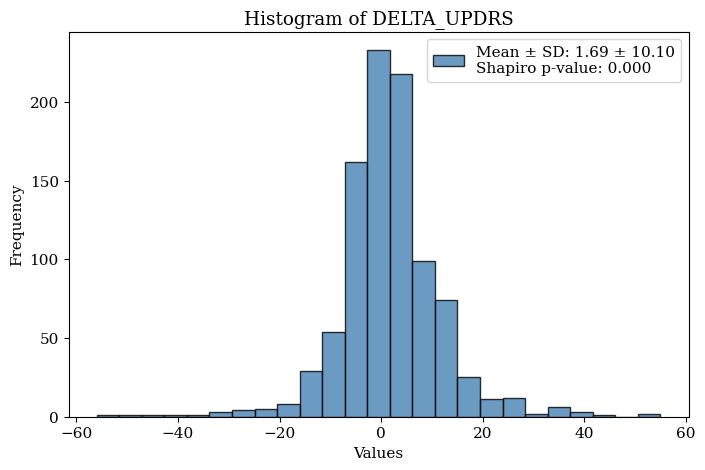

In [42]:
# Global style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

data = data_final['DELTA_UPDRS_previo'].to_list()

# Statistics
mean = np.mean(data)
std = np.std(data)

# Normality test (Shapiro-Wilk)
stat, p_value = stats.shapiro(data)

# Plot
plt.figure(figsize=(8,5))

plt.hist(
    data,
    bins=25,
    color="steelblue",
    edgecolor="black",
    alpha=0.8,
    label=f"Mean ± SD: {mean:.2f} ± {std:.2f}\nShapiro p-value: {p_value:.3f}"
)

plt.title("Histogram of DELTA_UPDRS")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.legend()

plt.show()

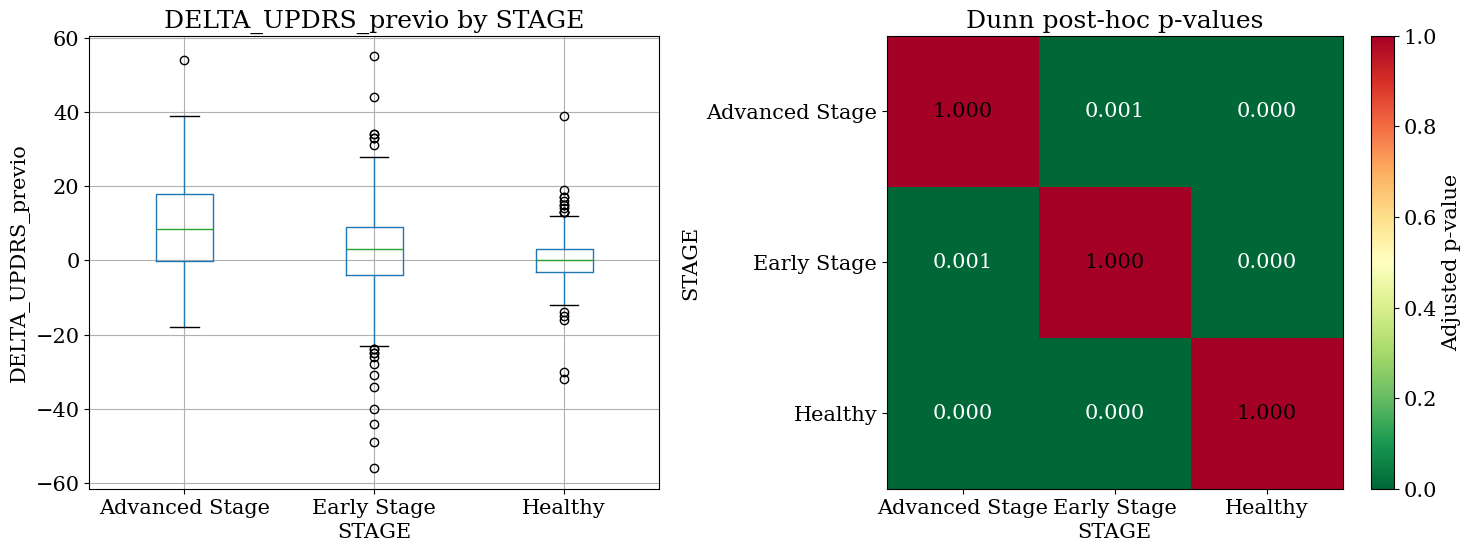

{'kruskal_statistic': np.float64(42.715754331817045), 'p_value': np.float64(5.301414989264109e-10), 'significant': np.True_, 'posthoc_dunn':                 Advanced Stage  Early Stage       Healthy
Advanced Stage    1.000000e+00     0.001346  9.754867e-08
Early Stage       1.345546e-03     1.000000  1.053898e-05
Healthy           9.754867e-08     0.000011  1.000000e+00}


In [43]:
result = kruskal_full_analysis(data_final, "DELTA_UPDRS_previo", "STAGE")
print(result)

# Analysis exaustivo items UPDRS

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import scikit_posthocs as sp

def kruskal_initial_analysis(df, col_num, col_cat, alpha=0.05):
    """
    Run Kruskal-Wallis test, optional Dunn post-hoc test, and plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    col_num : str
        Numeric column name.
    col_cat : str
        Categorical column name.
    alpha : float, default=0.05
        Significance level.
    plot : bool, default=True
        Whether to show plots.

    Returns
    -------
    dict
        Dictionary with Kruskal-Wallis results and, if significant,
        Dunn post-hoc p-value matrix.
    """

    # Clean data
    if col_num not in df.columns or col_cat not in df.columns:
        raise ValueError(f"Columns '{col_num}' and/or '{col_cat}' not found in DataFrame.")

    data = df[[col_num, col_cat]].dropna()

    if data.empty:
        raise ValueError("No data left after dropping missing values.")

    # Build groups
    grouped = data.groupby(col_cat)[col_num]
    groups = [group.values for _, group in grouped]

    if len(groups) < 2:
        raise ValueError("At least two groups are required for Kruskal-Wallis.")

    # Kruskal-Wallis test
    stat, p_value = kruskal(*groups)

    results = {
        "kruskal_statistic": stat,
        "p_value": p_value,
        "significant": p_value < alpha
    }

    val = '✅' if results["significant"] else '❌'
    
    return print(f'For {col_num} by {col_cat}:\nKruskal-Wallis statistic = {stat:.3f}, p-value = {p_value:.3f}, significant = {results["significant"]},{val}')

In [45]:
data = data_HY[['PATNO','EVENT_ID','STAGE'] + UPDRS_MOTOR+ UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR].copy()
data = data.loc[data['EVENT_ID'].isin(['V06','V08_v2','V10_v3']), :]

for item in (UPDRS_MOTOR + UPDRS_IMPACTO_MOTOR + UPDRS_NO_MOTOR):
    subset = data[['STAGE', item]].copy()
    kruskal_initial_analysis(subset, item, 'STAGE', alpha=0.05)

For NP3SPCH by STAGE:
Kruskal-Wallis statistic = 288.996, p-value = 0.000, significant = True,✅
For NP3FACXP by STAGE:
Kruskal-Wallis statistic = 485.773, p-value = 0.000, significant = True,✅
For NP3RIGN by STAGE:
Kruskal-Wallis statistic = 338.735, p-value = 0.000, significant = True,✅
For NP3RIGRU by STAGE:
Kruskal-Wallis statistic = 413.839, p-value = 0.000, significant = True,✅
For NP3RIGLU by STAGE:
Kruskal-Wallis statistic = 405.409, p-value = 0.000, significant = True,✅
For NP3RIGRL by STAGE:
Kruskal-Wallis statistic = 299.826, p-value = 0.000, significant = True,✅
For NP3RIGLL by STAGE:
Kruskal-Wallis statistic = 321.877, p-value = 0.000, significant = True,✅
For NP3FTAPR by STAGE:
Kruskal-Wallis statistic = 409.344, p-value = 0.000, significant = True,✅
For NP3FTAPL by STAGE:
Kruskal-Wallis statistic = 380.651, p-value = 0.000, significant = True,✅
For NP3HMOVR by STAGE:
Kruskal-Wallis statistic = 369.759, p-value = 0.000, significant = True,✅
For NP3HMOVL by STAGE:
Kruskal-W

---

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(project_root / 'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/Full_set.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df

,PATNO,EVENT_ID,ENRLLRRK2,ENRLGBA,SEX,RAWHITE,EDUCYRS,AGE_AT_VISIT,MCAALTTM,MCACUBE,...,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NHY,STAGE
0,3003_v1,1,0,0,0.0,1.0,16.0,56.7,1.0,1.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1
1,3003_v1,2,0,0,0.0,1.0,16.0,57.7,1.0,1.0,...,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,1
2,3003_v1,3,0,0,0.0,1.0,16.0,58.8,1.0,1.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,1
3,3003_v1,4,0,0,0.0,1.0,16.0,59.7,0.0,1.0,...,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,1
4,3018_v1,1,0,0,0.0,1.0,16.0,60.5,1.0,0.0,...,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3819,56435_v3,4,0,1,1.0,1.0,16.0,64.9,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2
3820,70818_v3,1,1,0,1.0,1.0,17.0,66.5,1.0,1.0,...,1.0,1.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0,1
3821,70818_v3,2,1,0,1.0,1.0,17.0,67.8,1.0,1.0,...,1.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,2.0,1
3822,70818_v3,3,1,0,1.0,1.0,17.0,68.6,1.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1


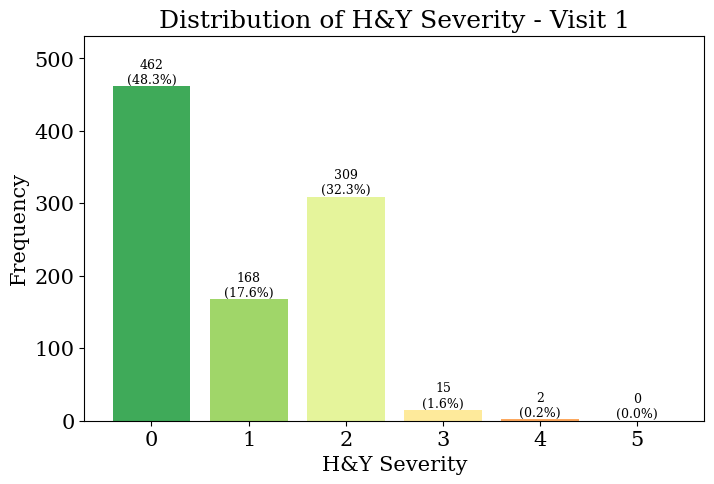

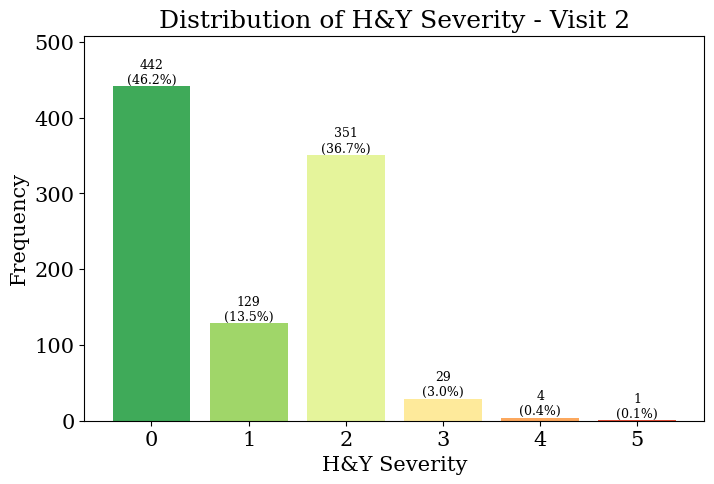

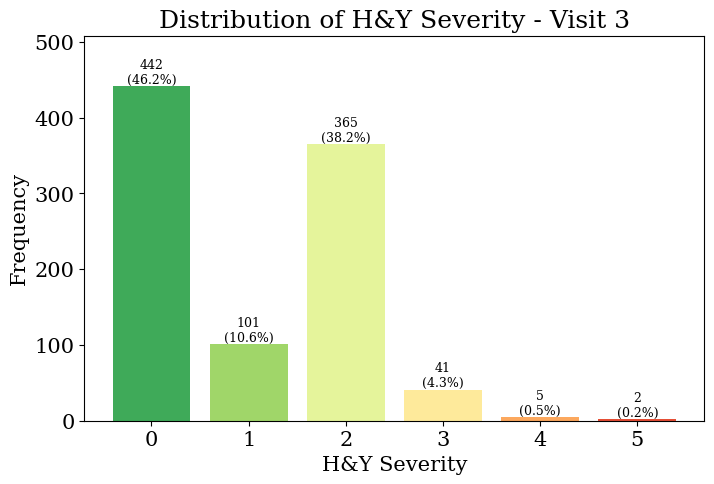

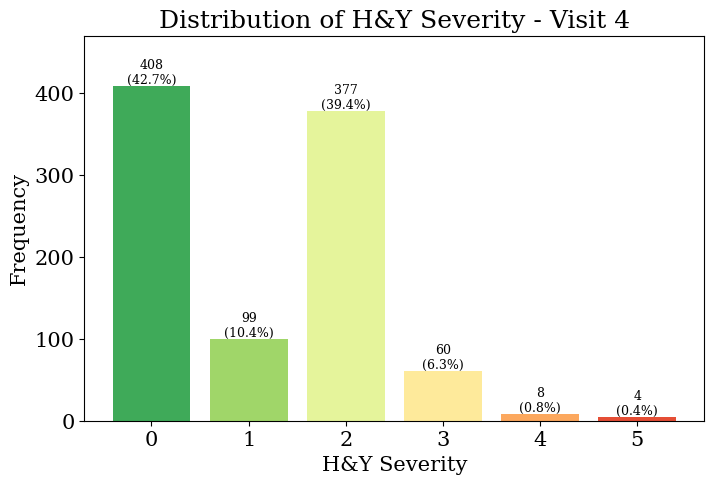

In [50]:
classes = [0, 1, 2, 3, 4, 5]

# Colores: menor gravedad verde, mayor gravedad rojo
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(classes)))

for event in [1, 2, 3, 4]:

    subset_nhy = df.loc[df['EVENT_ID'] == event, 'NHY'].dropna()

    counts = [sum(subset_nhy == c) for c in classes]
    total = sum(counts)

    percentages = [(count / total) * 100 if total > 0 else 0 for count in counts]

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(classes, counts, color=colors)

    ax.set_xlabel("H&Y Severity")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of H&Y Severity - Visit {event}")
    ax.set_xticks(classes)
    ax.set_ylim(0, max(counts) * 1.15 if max(counts) > 0 else 1)

    # Añadir contador y porcentaje encima de cada barra
    for bar, count, percentage in zip(bars, counts, percentages):
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{count}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.show()


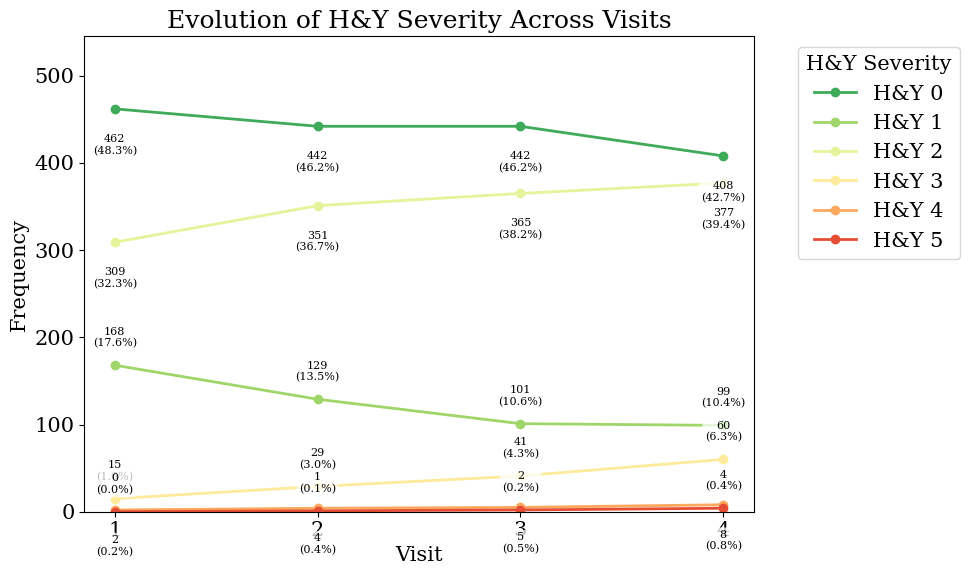

In [61]:
import matplotlib.pyplot as plt
import numpy as np

classes = [0, 1, 2, 3, 4, 5]
events = [1, 2, 3, 4]

# Colores: menor gravedad verde, mayor gravedad rojo
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(classes)))

nhy_counts = {c: [] for c in classes}
nhy_percentages = {c: [] for c in classes}

for event in events:
    subset_nhy = df.loc[df['EVENT_ID'] == event, 'NHY'].dropna()
    total = len(subset_nhy)

    for c in classes:
        count = sum(subset_nhy == c)
        percentage = (count / total) * 100 if total > 0 else 0

        nhy_counts[c].append(count)
        nhy_percentages[c].append(percentage)

fig, ax = plt.subplots(figsize=(10, 6))

# Desplazamientos para evitar solapamiento de etiquetas
label_offsets = {
    0: (0, -18),
    1: (0, 12),
    2: (0, -18),
    3: (0, 12),
    4: (0, -18),
    5: (0, 12)
}

vertical_alignment = {
    0: "top",
    1: "bottom",
    2: "top",
    3: "bottom",
    4: "top",
    5: "bottom"
}

for c, color in zip(classes, colors):
    ax.plot(
        events,
        nhy_counts[c],
        marker="o",
        linewidth=2,
        color=color,
        label=f"H&Y {c}"
    )

    for event, count, percentage in zip(events, nhy_counts[c], nhy_percentages[c]):
        ax.annotate(
            f"{count}\n({percentage:.1f}%)",
            xy=(event, count),
            xytext=label_offsets[c],
            textcoords="offset points",
            ha="center",
            va=vertical_alignment[c],
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            )
        )

ax.set_xlabel("Visit")
ax.set_ylabel("Frequency")
ax.set_title("Evolution of H&Y Severity Across Visits")
ax.set_xticks(events)

ax.set_ylim(0, max(max(v) for v in nhy_counts.values()) * 1.18)

ax.legend(
    title="H&Y Severity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

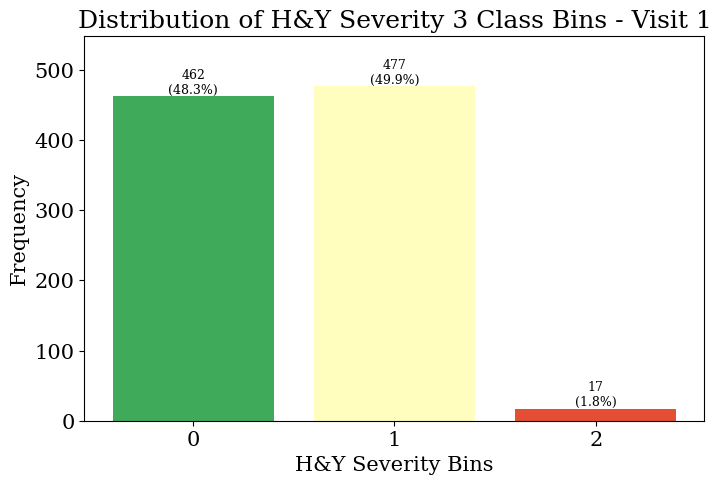

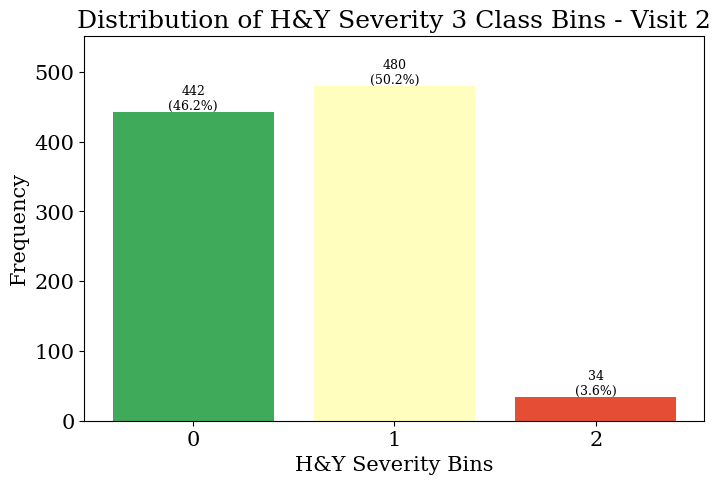

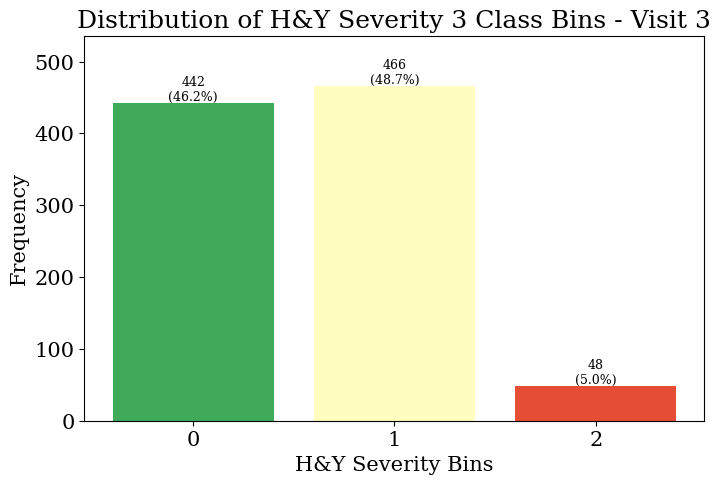

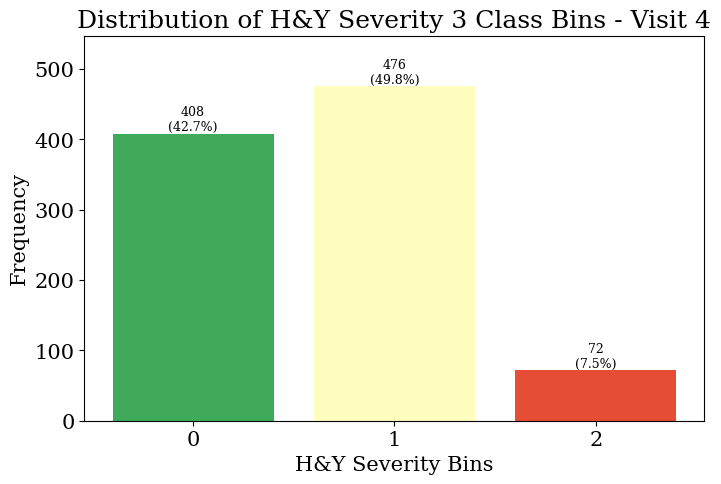

In [55]:
stage = [0, 1, 2]

# Colores: menor gravedad verde, mayor gravedad rojo
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(stage)))

for event in [1, 2, 3, 4]:

    subset_nhy = df.loc[df['EVENT_ID'] == event, 'STAGE'].dropna()

    counts = [sum(subset_nhy == c) for c in stage]
    total = sum(counts)

    percentages = [(count / total) * 100 if total > 0 else 0 for count in counts]

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(stage, counts, color=colors)

    ax.set_xlabel("H&Y Severity Bins")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of H&Y Severity 3 Class Bins - Visit {event}")
    ax.set_xticks(stage)
    ax.set_ylim(0, max(counts) * 1.15 if max(counts) > 0 else 1)

    # Añadir contador y porcentaje encima de cada barra
    for bar, count, percentage in zip(bars, counts, percentages):
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{count}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.show()

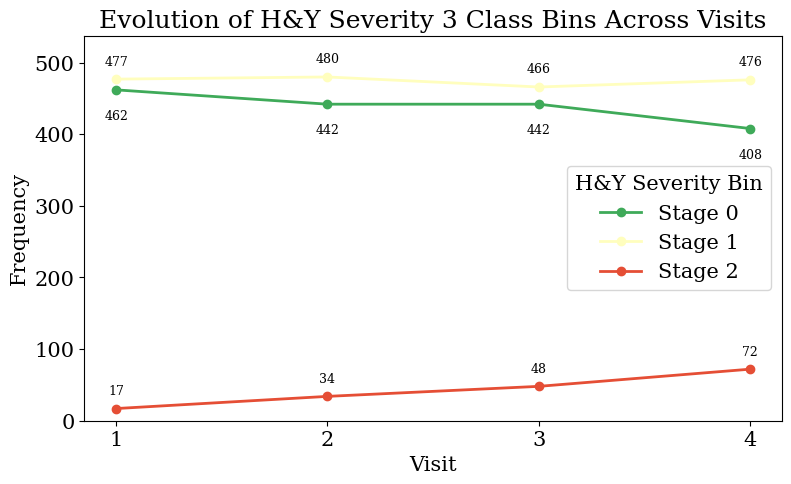

In [60]:

stage = [0, 1, 2]
events = [1, 2, 3, 4]

colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(stage)))

stage_counts = {s: [] for s in stage}

for event in events:
    subset_stage = df.loc[df['EVENT_ID'] == event, 'STAGE'].dropna()

    for s in stage:
        count = sum(subset_stage == s)
        stage_counts[s].append(count)

fig, ax = plt.subplots(figsize=(9, 5))

# Desplazamiento vertical de las etiquetas por clase
label_offsets = {
    0: -14,   # Stage 0: etiqueta debajo del punto
    1: 8,     # Stage 1: etiqueta encima del punto
    2: 8      # Stage 2: etiqueta encima del punto
}

vertical_alignment = {
    0: "top",
    1: "bottom",
    2: "bottom"
}

for s, color in zip(stage, colors):
    ax.plot(
        events,
        stage_counts[s],
        marker='o',
        linewidth=2,
        color=color,
        label=f"Stage {s}"
    )

    for event, count in zip(events, stage_counts[s]):
        ax.annotate(
            str(count),
            xy=(event, count),
            xytext=(0, label_offsets[s]),
            textcoords="offset points",
            ha="center",
            va=vertical_alignment[s],
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.7
            )
        )

ax.set_xlabel("Visit")
ax.set_ylabel("Frequency")
ax.set_title("Evolution of H&Y Severity 3 Class Bins Across Visits")
ax.set_xticks(events)

ax.set_ylim(0, max(max(v) for v in stage_counts.values()) * 1.12)

ax.legend(title="H&Y Severity Bin")

plt.show()